In [ ]:
# ============================================================
# CELL 0: Fix SciKeras / scikit-learn version incompatibility
# ============================================================
!pip install scikit-learn==1.5.2 scikeras==0.13.0 -q

In [ ]:
# ============================================================
# CELL 1: Imports and Global Matplotlib Configuration
# ============================================================
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasClassifier
import time
import os

# Create directory to store all figures (both .eps and .pdf)
os.makedirs("figures", exist_ok=True)

# Global font settings: Times New Roman, size 14, bold axes labels/ticks
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = [font_name, 'Liberation Serif', 'DejaVu Serif']
mpl.rcParams['font.size'] = 14
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['figure.dpi'] = 600

# Universal figure-saving function: saves BOTH .eps and .pdf at 600 DPI
def save_figure(fig, filename):
    """
    Saves a matplotlib figure as both .eps and .pdf at 600 DPI.
    In LaTeX, reference the figure WITHOUT extension so pdflatex
    auto-selects the .pdf (avoids Ghostscript EPS->PDF conversion timeout).
    """
    fig.savefig(f"figures/{filename}.eps", format='eps', dpi=600, bbox_inches='tight')
    fig.savefig(f"figures/{filename}.pdf", format='pdf', dpi=600, bbox_inches='tight')
    print(f"Saved: figures/{filename}.eps and figures/{filename}.pdf")

print("Setup complete. TensorFlow version:", tf.__version__)

Setup complete. TensorFlow version: 2.20.0


In [ ]:
# ============================================================
# CELL 1a: Install and Register Times New Roman (via liberation-fonts)
# ============================================================
!apt-get install -y fonts-liberation > /dev/null 2>&1

import matplotlib.font_manager as fm

# Liberation Serif is metric-compatible with Times New Roman
font_path = "/usr/share/fonts/truetype/liberation/LiberationSerif-Regular.ttf"
font_path_bold = "/usr/share/fonts/truetype/liberation/LiberationSerif-Bold.ttf"

fm.fontManager.addfont(font_path)
fm.fontManager.addfont(font_path_bold)

# Rebuild font cache so matplotlib picks it up
fm._load_fontmanager(try_read_cache=False)

font_name = fm.FontProperties(fname=font_path).get_name()
print("Registered font:", font_name)

Registered font: Liberation Serif


In [ ]:
# ============================================================
# CELL 2: Task 1 - Dataset Exploration
# ============================================================
# Load Fashion-MNIST dataset (built into Keras)
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Class label names for Fashion-MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Print dataset dimensions
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)
print("Number of classes:", len(np.unique(y_train)))
print("Pixel value range: [{}, {}]".format(x_train.min(), x_train.max()))

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)
Number of classes: 10
Pixel value range: [0, 255]


Saved: figures/fig1_sample_images.eps and figures/fig1_sample_images.pdf


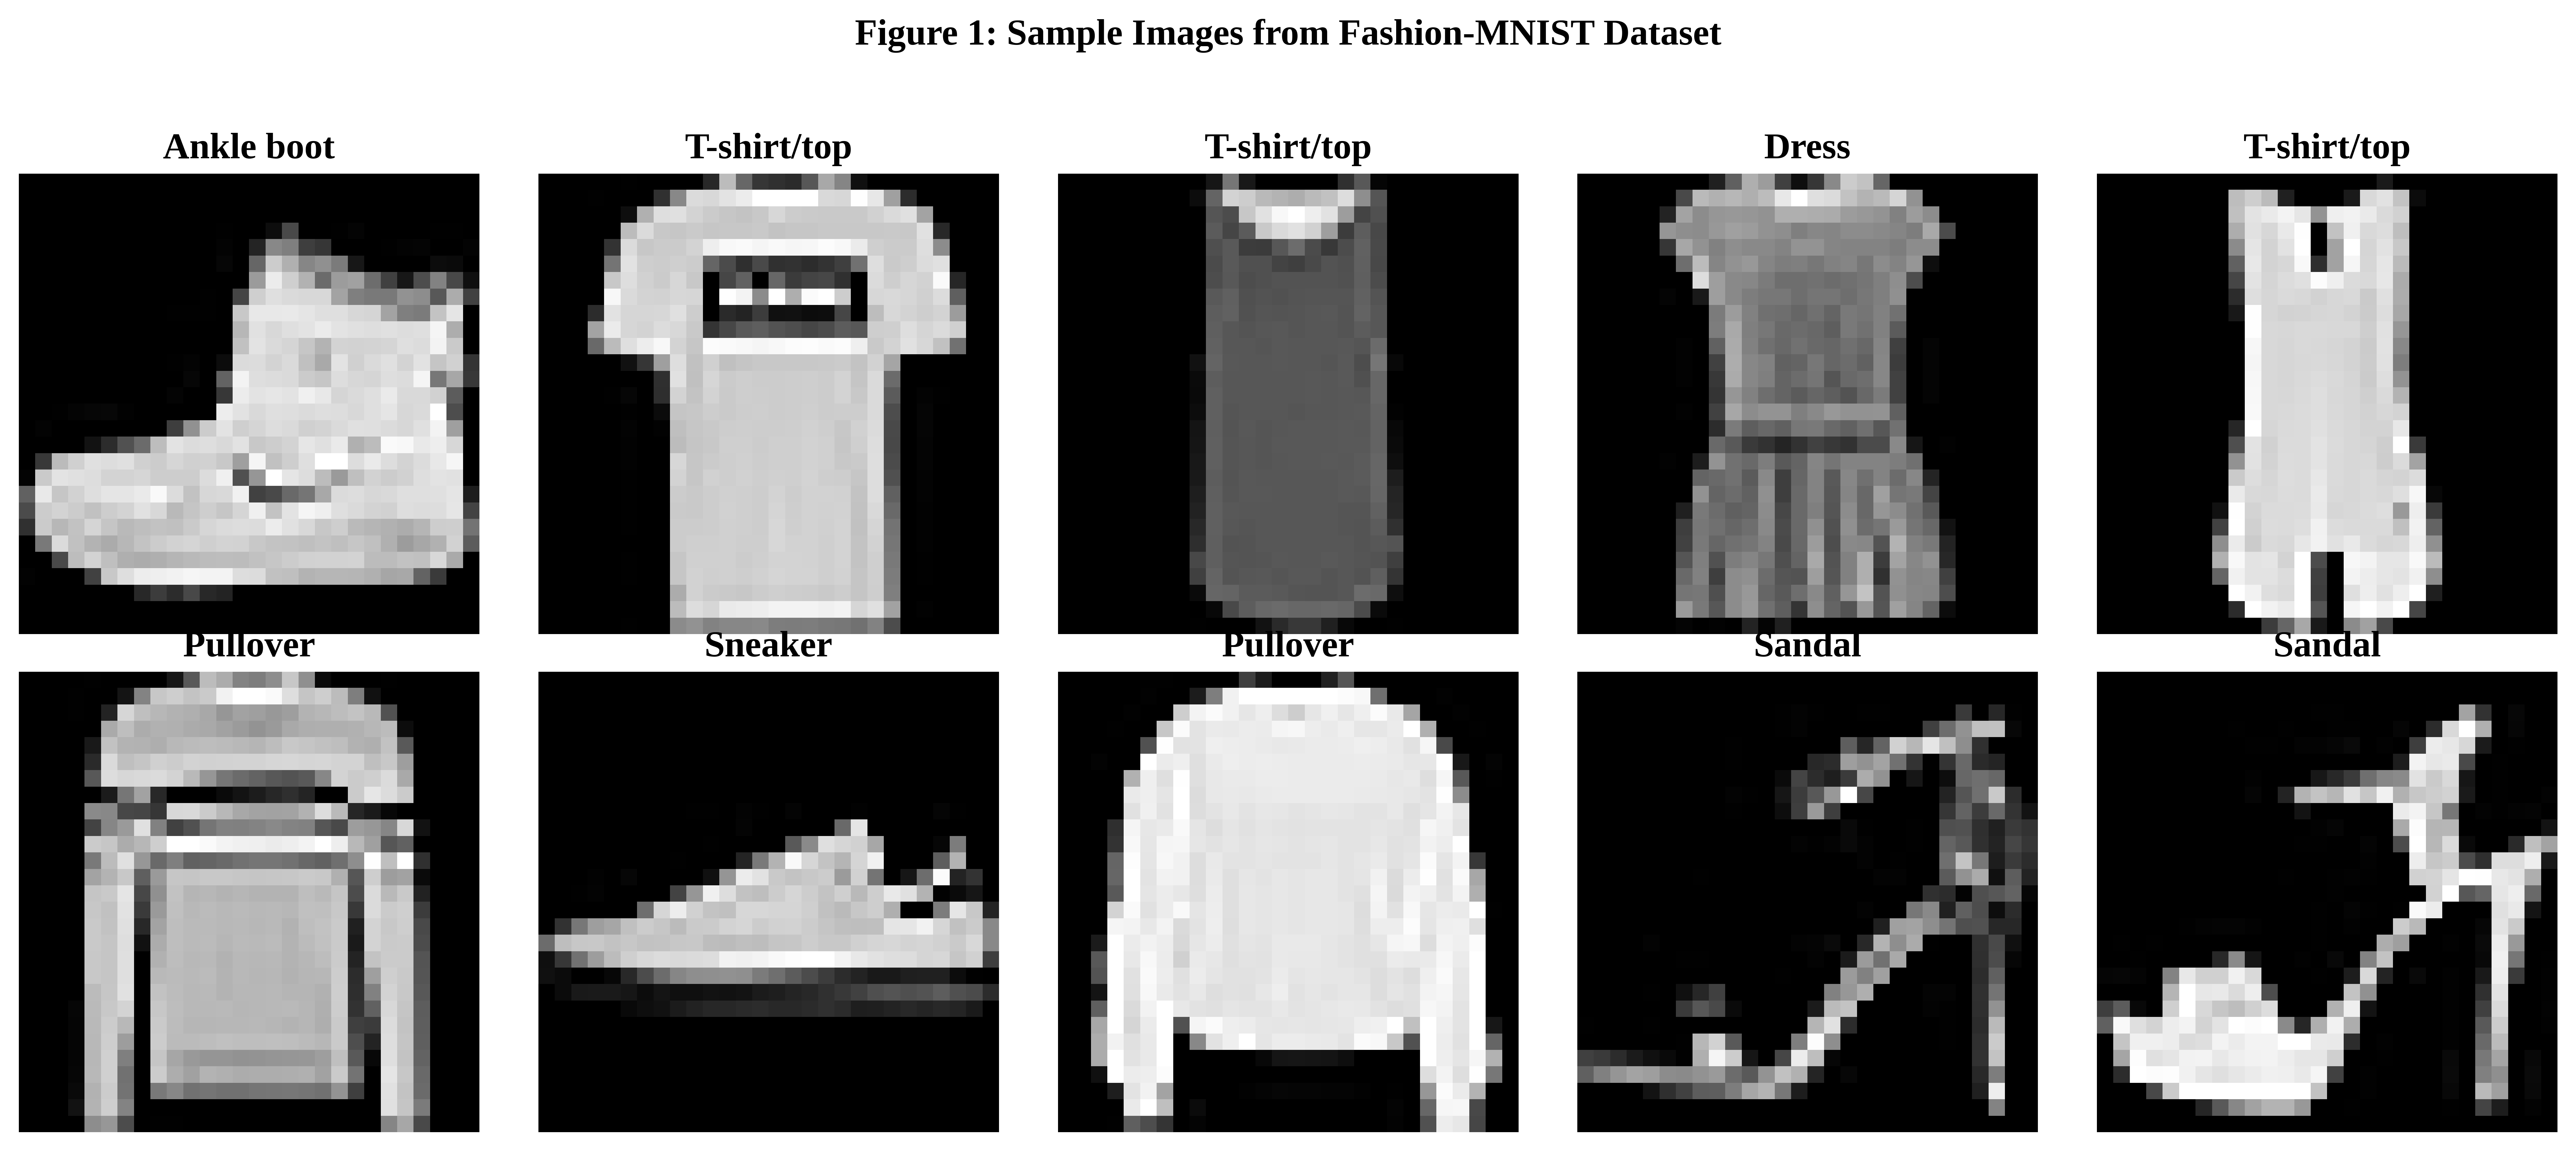

In [ ]:
# ============================================================
# CELL 3: Figure 1 - Display Ten Sample Images
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(x_train[i], cmap='gray')
    axes[i].set_title(class_names[y_train[i]], fontsize=14, fontweight='bold')
    axes[i].axis('off')

fig.suptitle("Figure 1: Sample Images from Fashion-MNIST Dataset",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_figure(fig, "fig1_sample_images")
plt.show()

Inference:
 Figure 1 displays ten representative samples from Fashion-MNIST, one per common category. The grayscale 28x28 images show clear inter-class shape variation (e.g., trousers vs. bags), confirming the dataset's suitability for a classification task requiring spatial feature discrimination.

Saved: figures/fig2_class_distribution.eps and figures/fig2_class_distribution.pdf


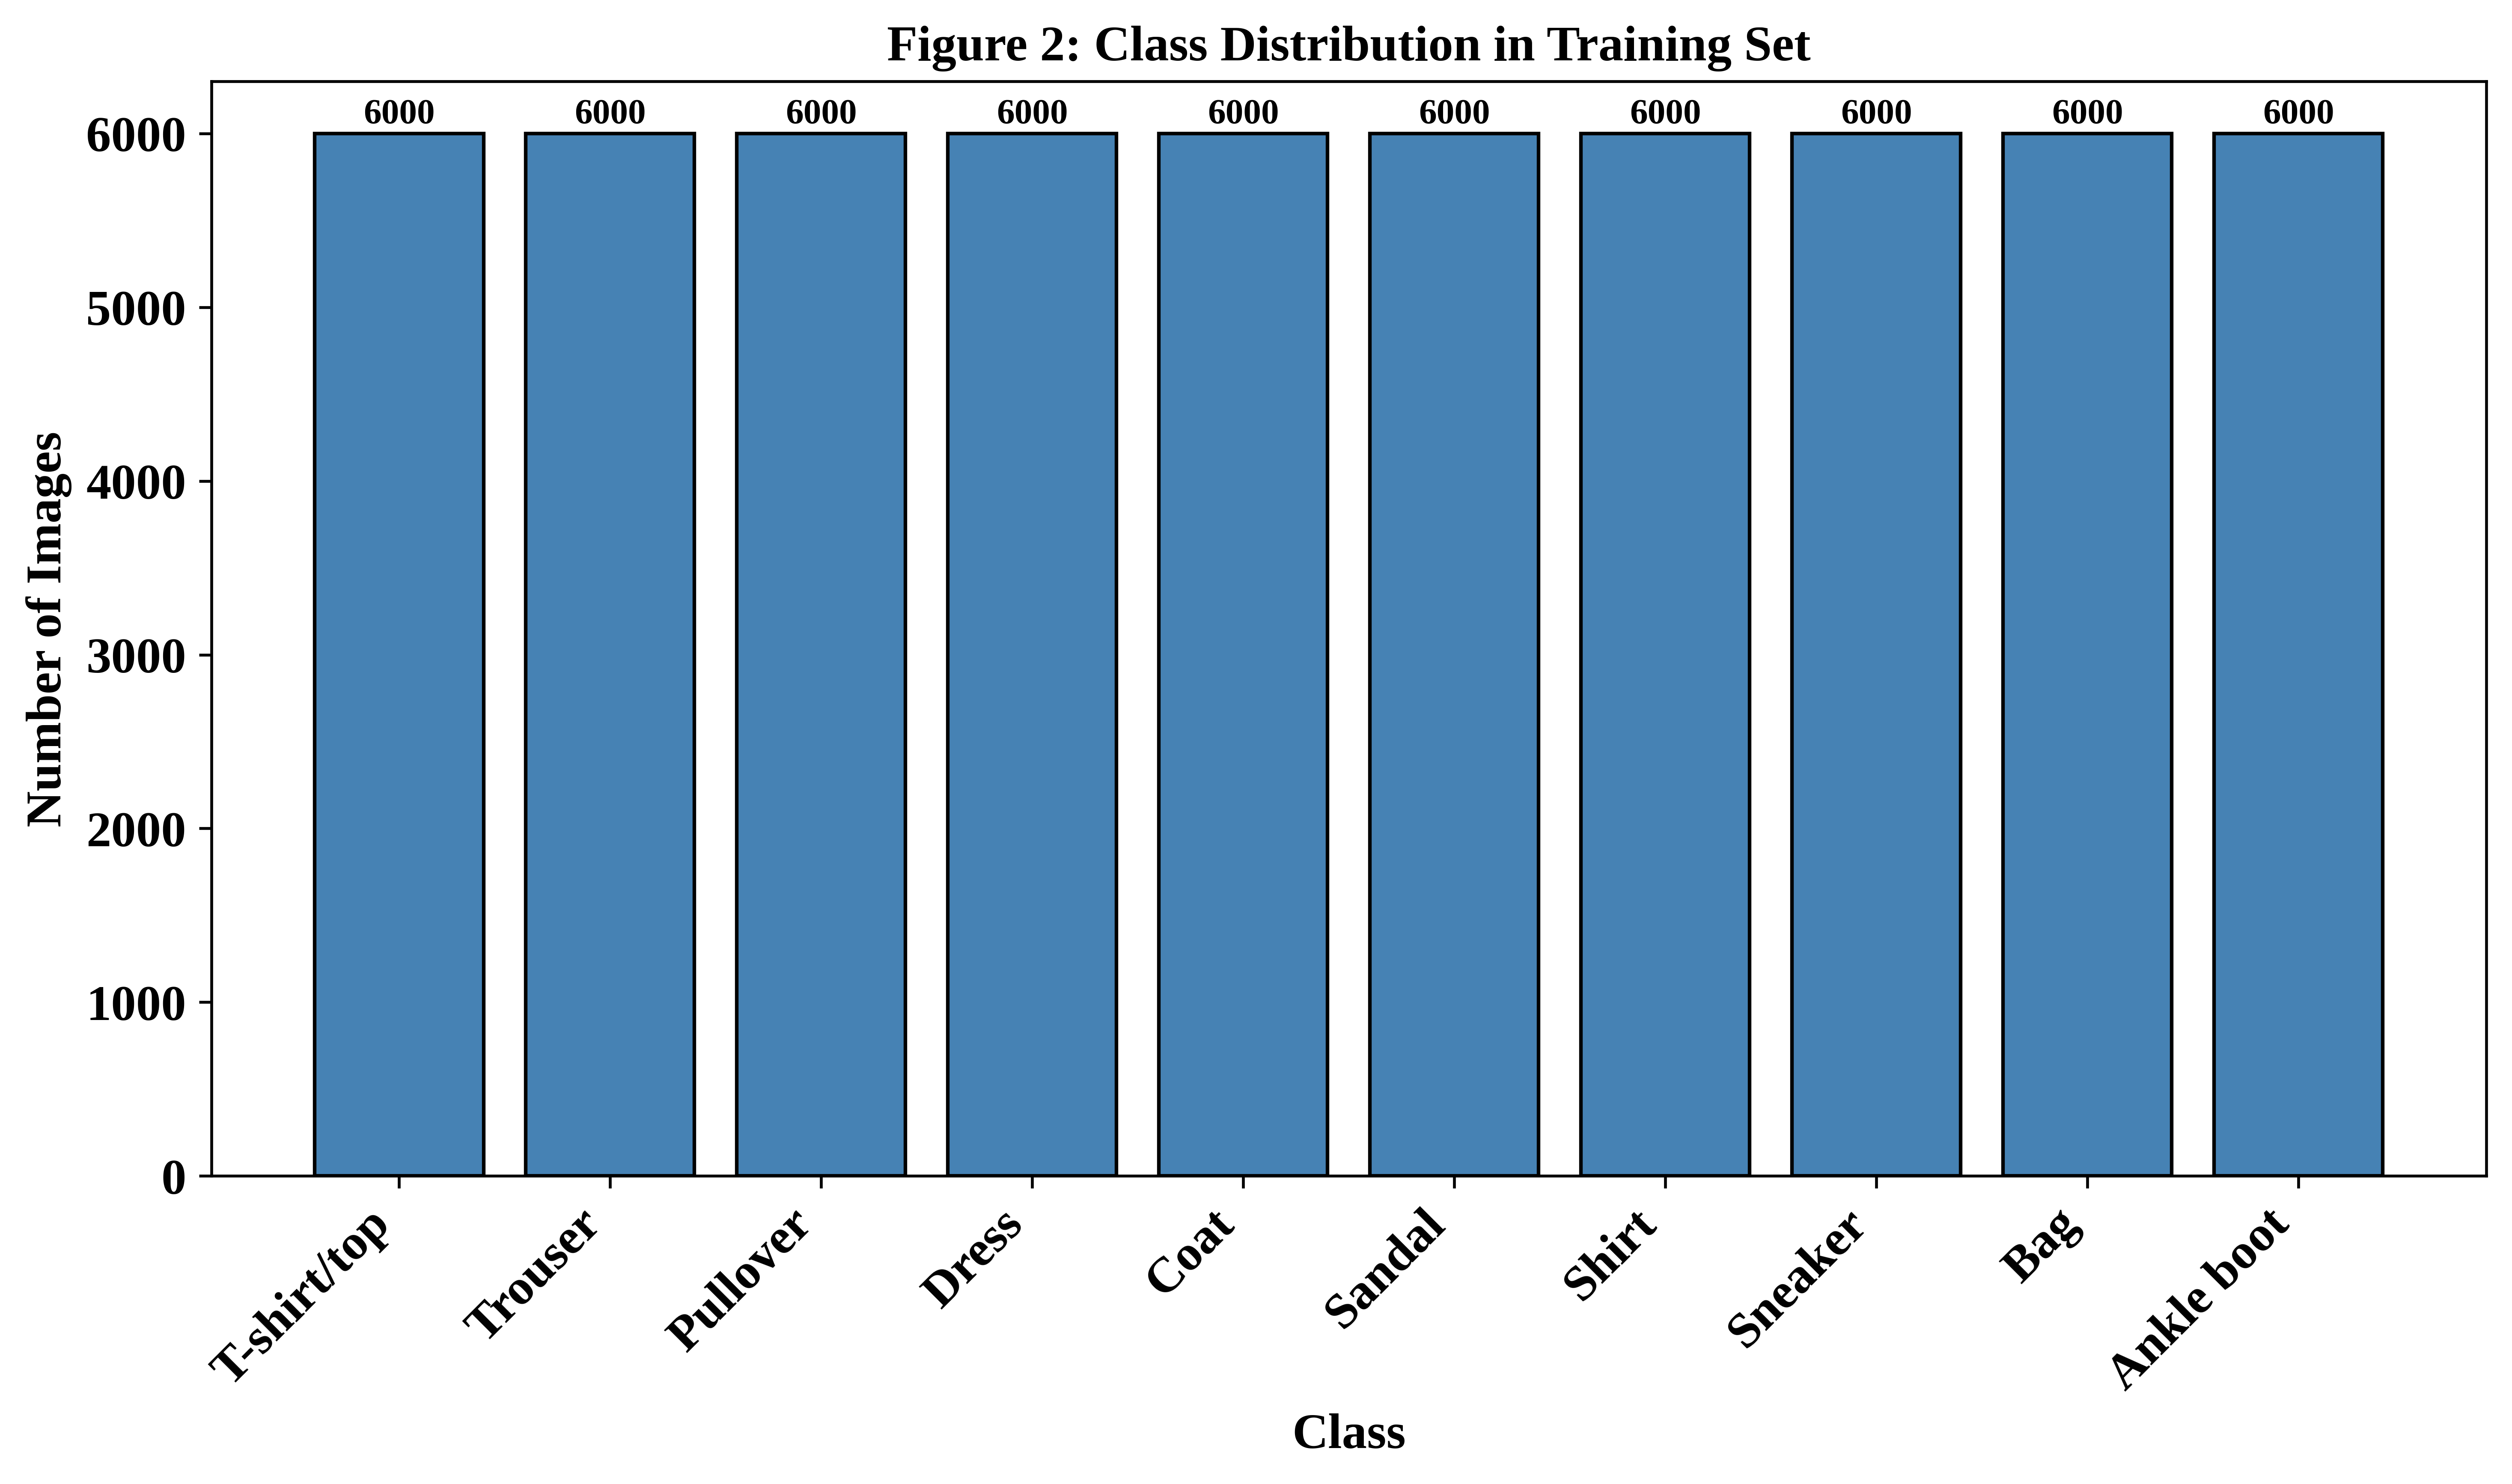

In [ ]:
# ============================================================
# CELL 4: Figure 2 - Class Distribution Plot
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))
unique, counts = np.unique(y_train, return_counts=True)
bars = ax.bar([class_names[i] for i in unique], counts, color='steelblue', edgecolor='black')

ax.set_xlabel("Class", fontsize=14, fontweight='bold')
ax.set_ylabel("Number of Images", fontsize=14, fontweight='bold')
ax.set_title("Figure 2: Class Distribution in Training Set", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=10)

plt.tight_layout()
save_figure(fig, "fig2_class_distribution")
plt.show()



Inference:
Figure 2 confirms that all 10 classes contain exactly 6000 training images,indicating a perfectly balanced dataset. This eliminates the need for class re-weighting or resampling strategies during model training.

In [ ]:
# ============================================================
# CELL 5: Task 2 - Data Preprocessing (Flatten + Normalize + One-Hot)
# ============================================================
print("Shape BEFORE preprocessing:")
print("  x_train:", x_train.shape, " x_test:", x_test.shape)

# Flatten 28x28 images into 784-length vectors
x_train_flat = x_train.reshape(x_train.shape[0], 784).astype('float32')
x_test_flat = x_test.reshape(x_test.shape[0], 784).astype('float32')

# Normalize pixel values from [0,255] to [0,1]
x_train_flat /= 255.0
x_test_flat /= 255.0

# Convert integer labels into one-hot encoded vectors
y_train_onehot = keras.utils.to_categorical(y_train, num_classes=10)
y_test_onehot = keras.utils.to_categorical(y_test, num_classes=10)

print("\nShape AFTER preprocessing:")
print("  x_train_flat:", x_train_flat.shape, " x_test_flat:", x_test_flat.shape)
print("  y_train_onehot:", y_train_onehot.shape, " y_test_onehot:", y_test_onehot.shape)
print("\nNormalized pixel range: [{:.2f}, {:.2f}]".format(x_train_flat.min(), x_train_flat.max()))

Shape BEFORE preprocessing:
  x_train: (60000, 28, 28)  x_test: (10000, 28, 28)

Shape AFTER preprocessing:
  x_train_flat: (60000, 784)  x_test_flat: (10000, 784)
  y_train_onehot: (60000, 10)  y_test_onehot: (10000, 10)

Normalized pixel range: [0.00, 1.00]


In [ ]:
# ============================================================
# CELL 6: Task 3 - Build Baseline MLP Model
# ============================================================
def build_baseline_model():
    model = models.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu', name='hidden_layer_1'),
        layers.Dense(64, activation='relu', name='hidden_layer_2'),
        layers.Dense(10, activation='softmax', name='output_layer')
    ])
    return model

baseline_model = build_baseline_model()
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# CELL 7: Task 4 - Compile and Train Baseline Model
# ============================================================
baseline_model.compile(optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

start_time = time.time()
history_baseline = baseline_model.fit(x_train_flat, y_train_onehot,
                                       epochs=20, batch_size=32,
                                       validation_split=0.1, verbose=1)
baseline_train_time = time.time() - start_time
print(f"\nBaseline training time: {baseline_train_time:.2f} seconds")

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8221 - loss: 0.4959 - val_accuracy: 0.8503 - val_loss: 0.4051
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8656 - loss: 0.3705 - val_accuracy: 0.8568 - val_loss: 0.3883
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8773 - loss: 0.3346 - val_accuracy: 0.8623 - val_loss: 0.3721
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8849 - loss: 0.3103 - val_accuracy: 0.8663 - val_loss: 0.3775
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8922 - loss: 0.2917 - val_accuracy: 0.8742 - val_loss: 0.3529
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8971 - loss: 0.2753 - val_accuracy: 0.8702 - val_loss: 0.3737
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9016 - loss: 0.2615 - val_accuracy: 0.8720 - val_loss: 0.3722
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9058 - loss: 0.2500 - 

Saved: figures/fig3_train_accuracy.eps and figures/fig3_train_accuracy.pdf


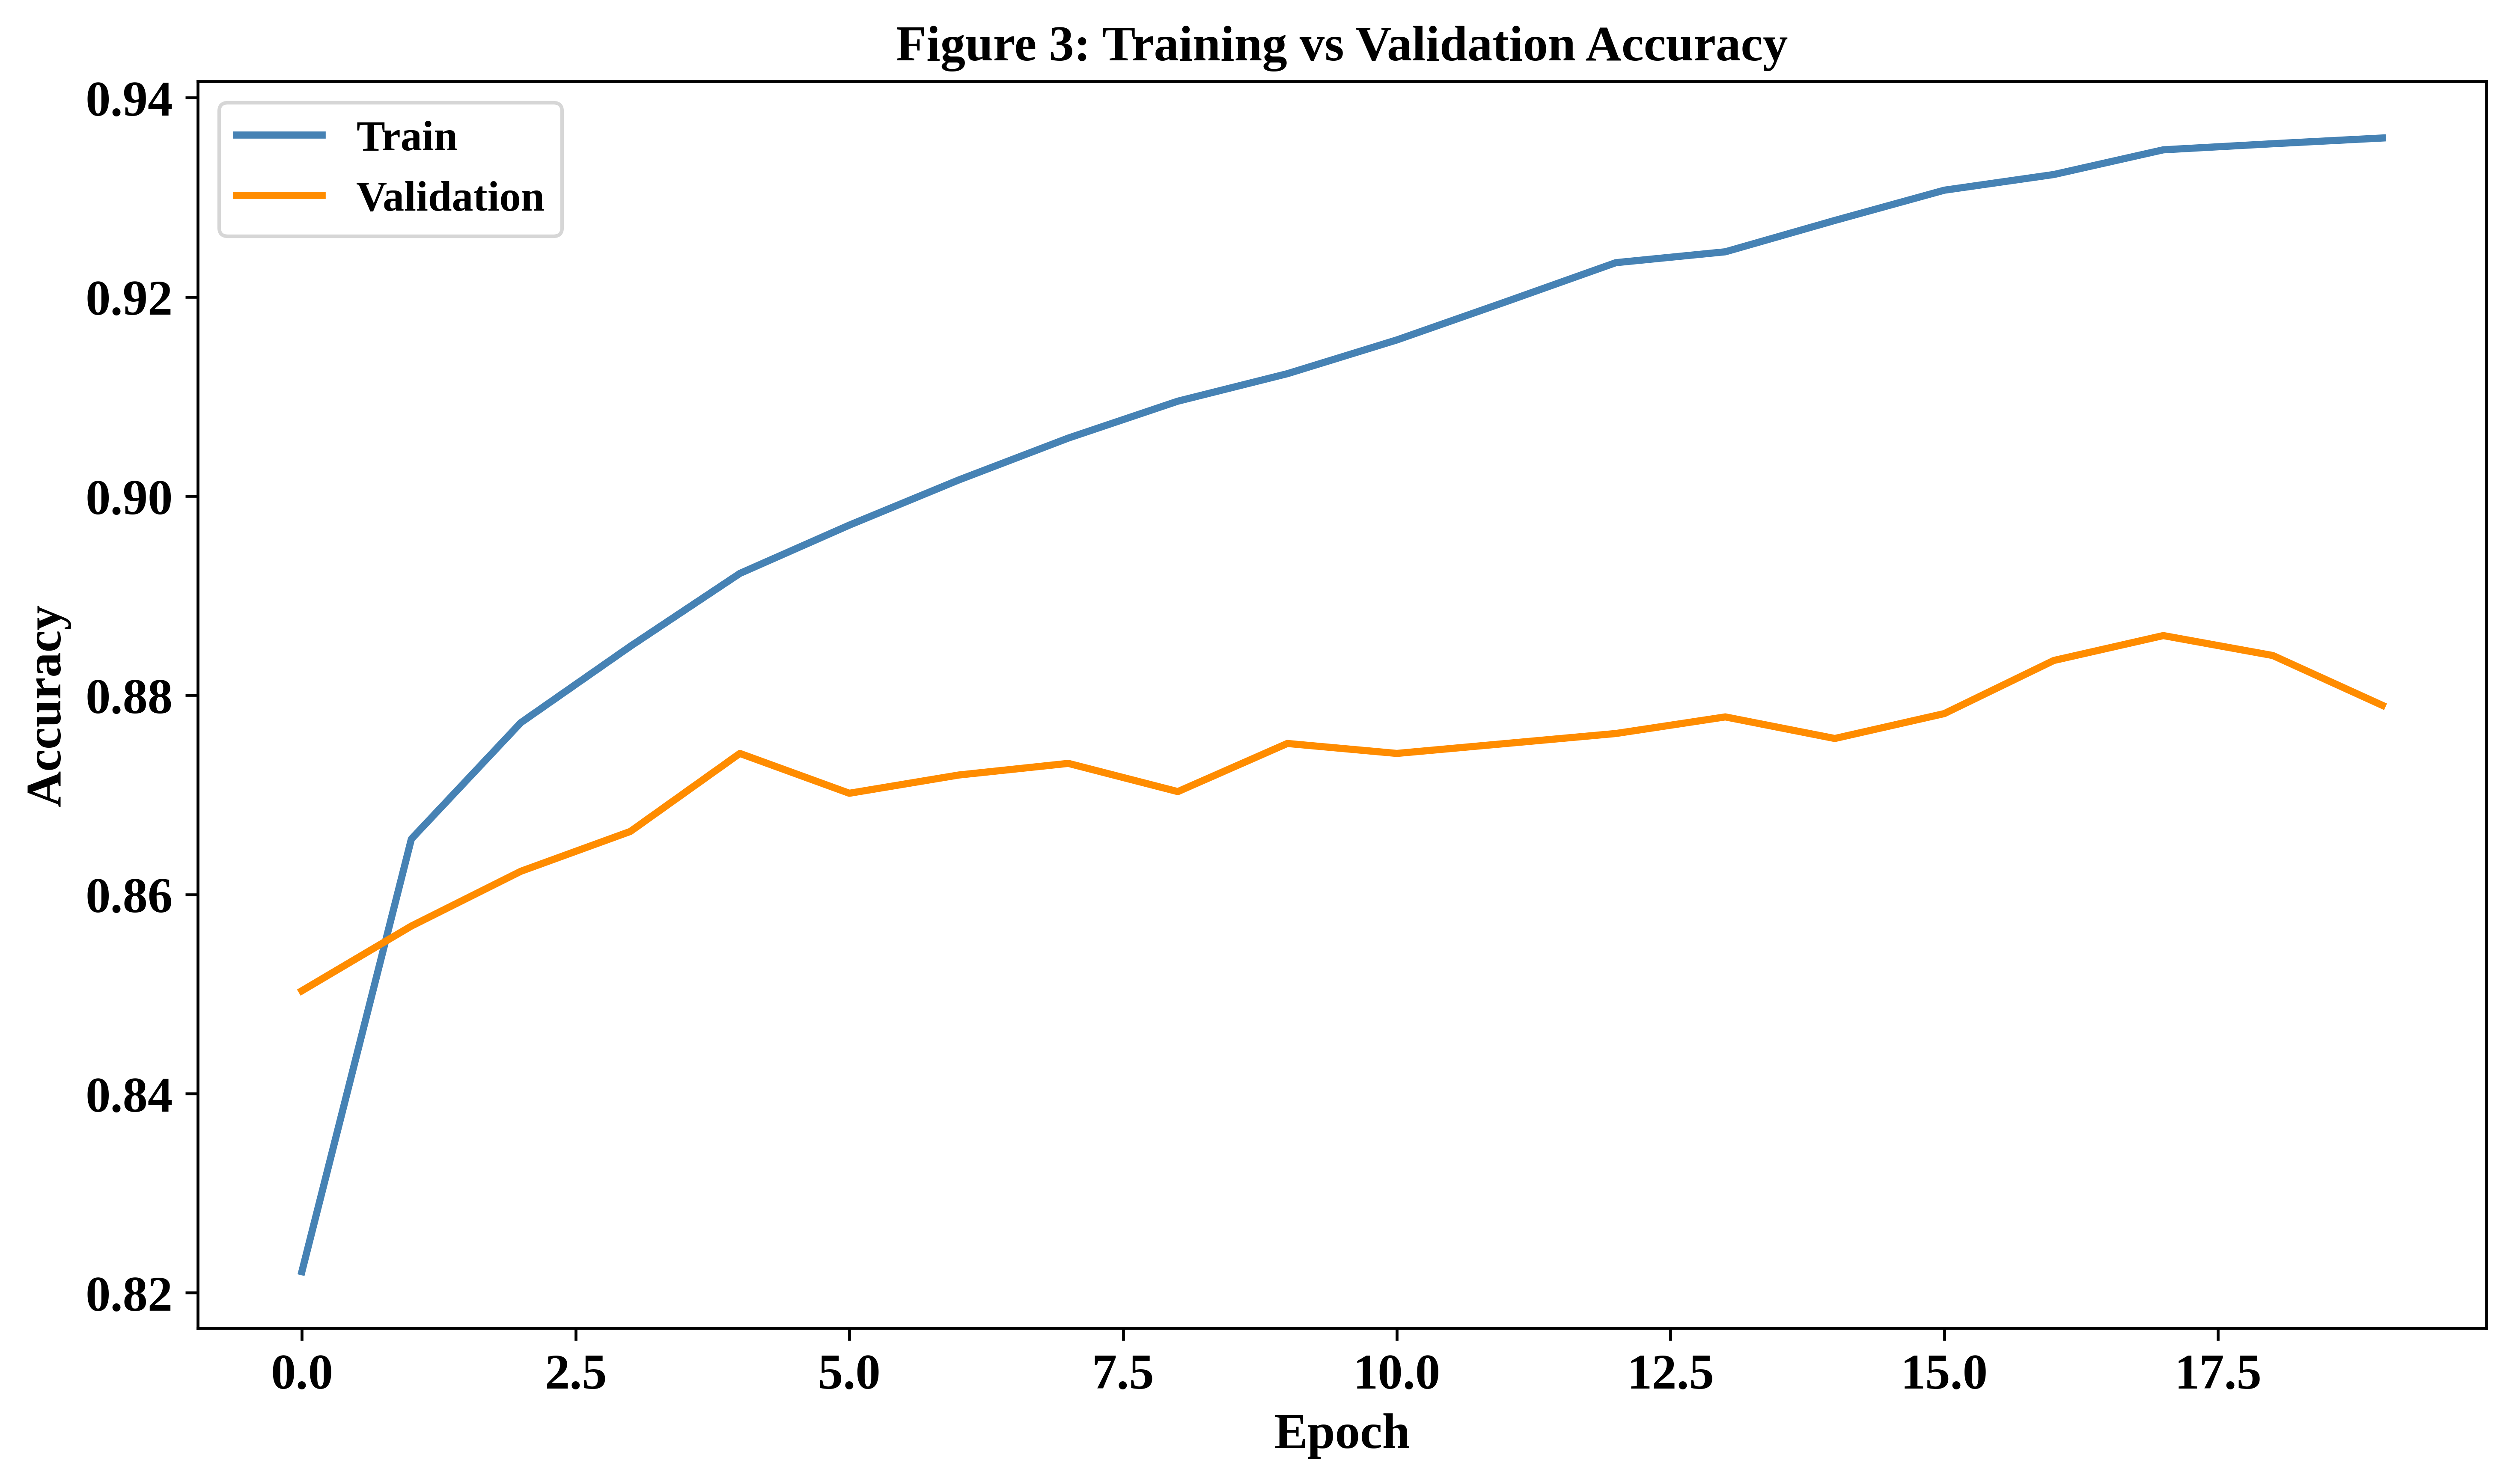

Saved: figures/fig4_val_accuracy.eps and figures/fig4_val_accuracy.pdf


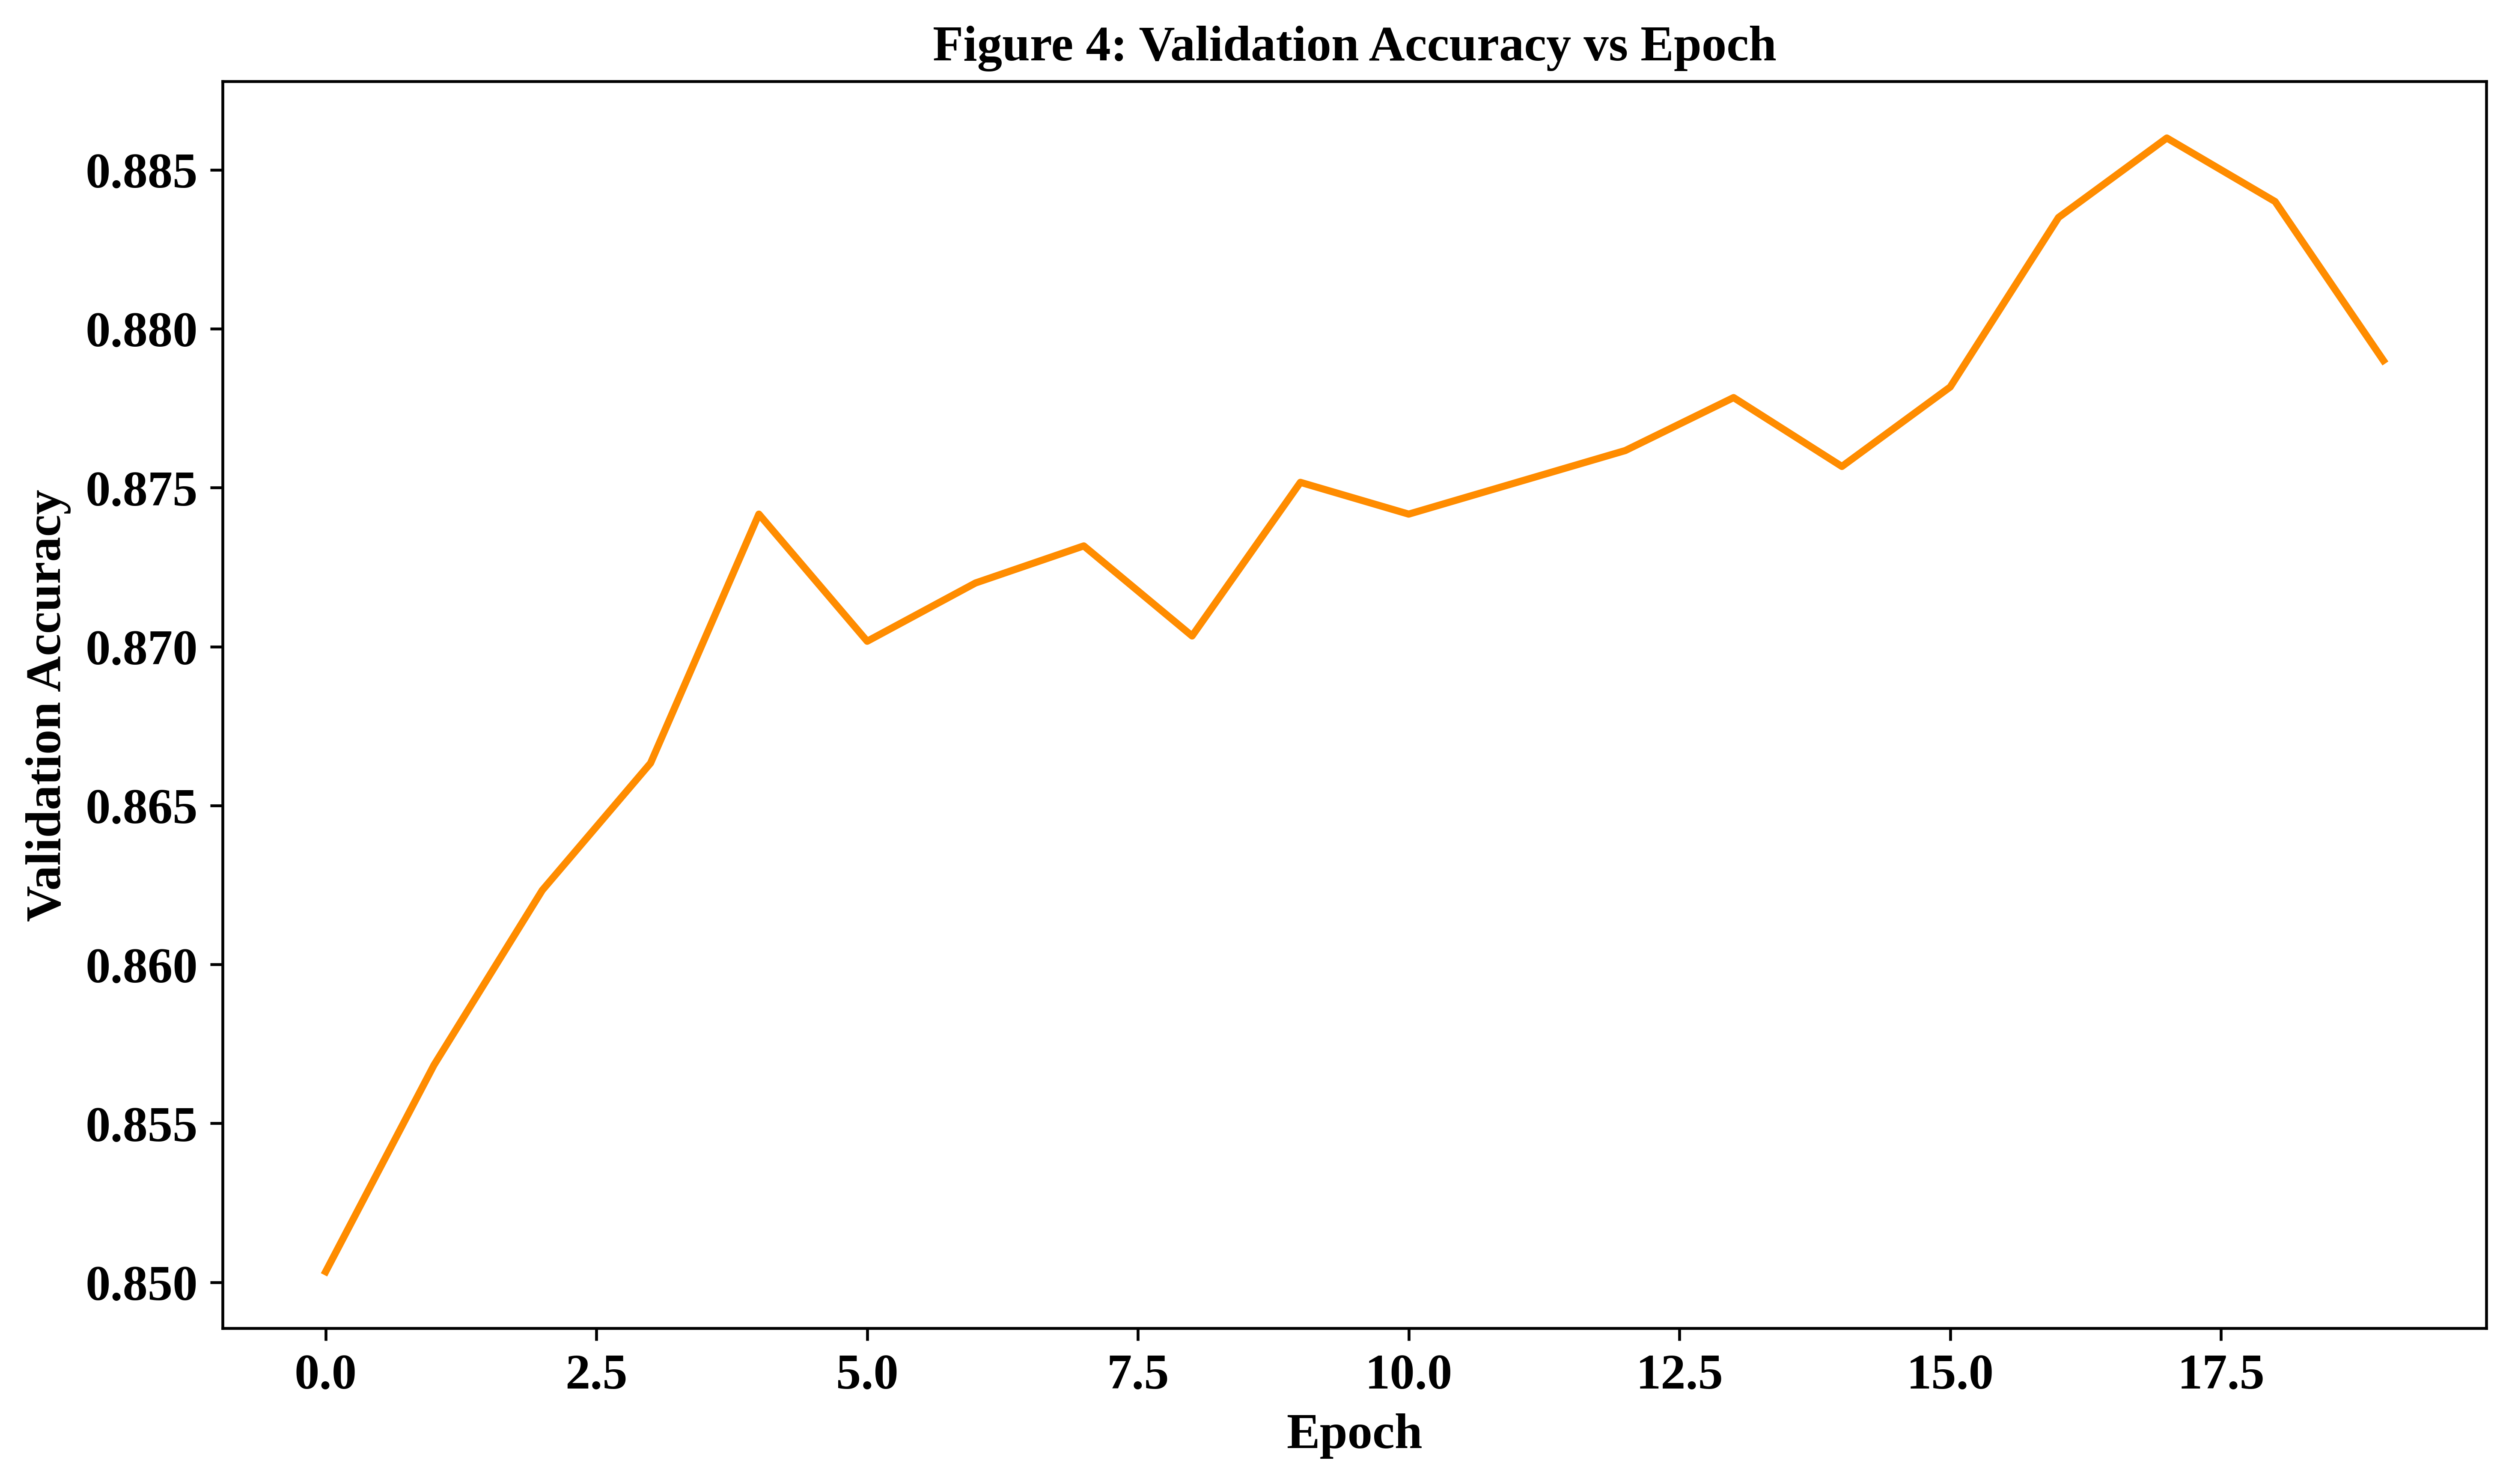

Saved: figures/fig5_train_loss.eps and figures/fig5_train_loss.pdf


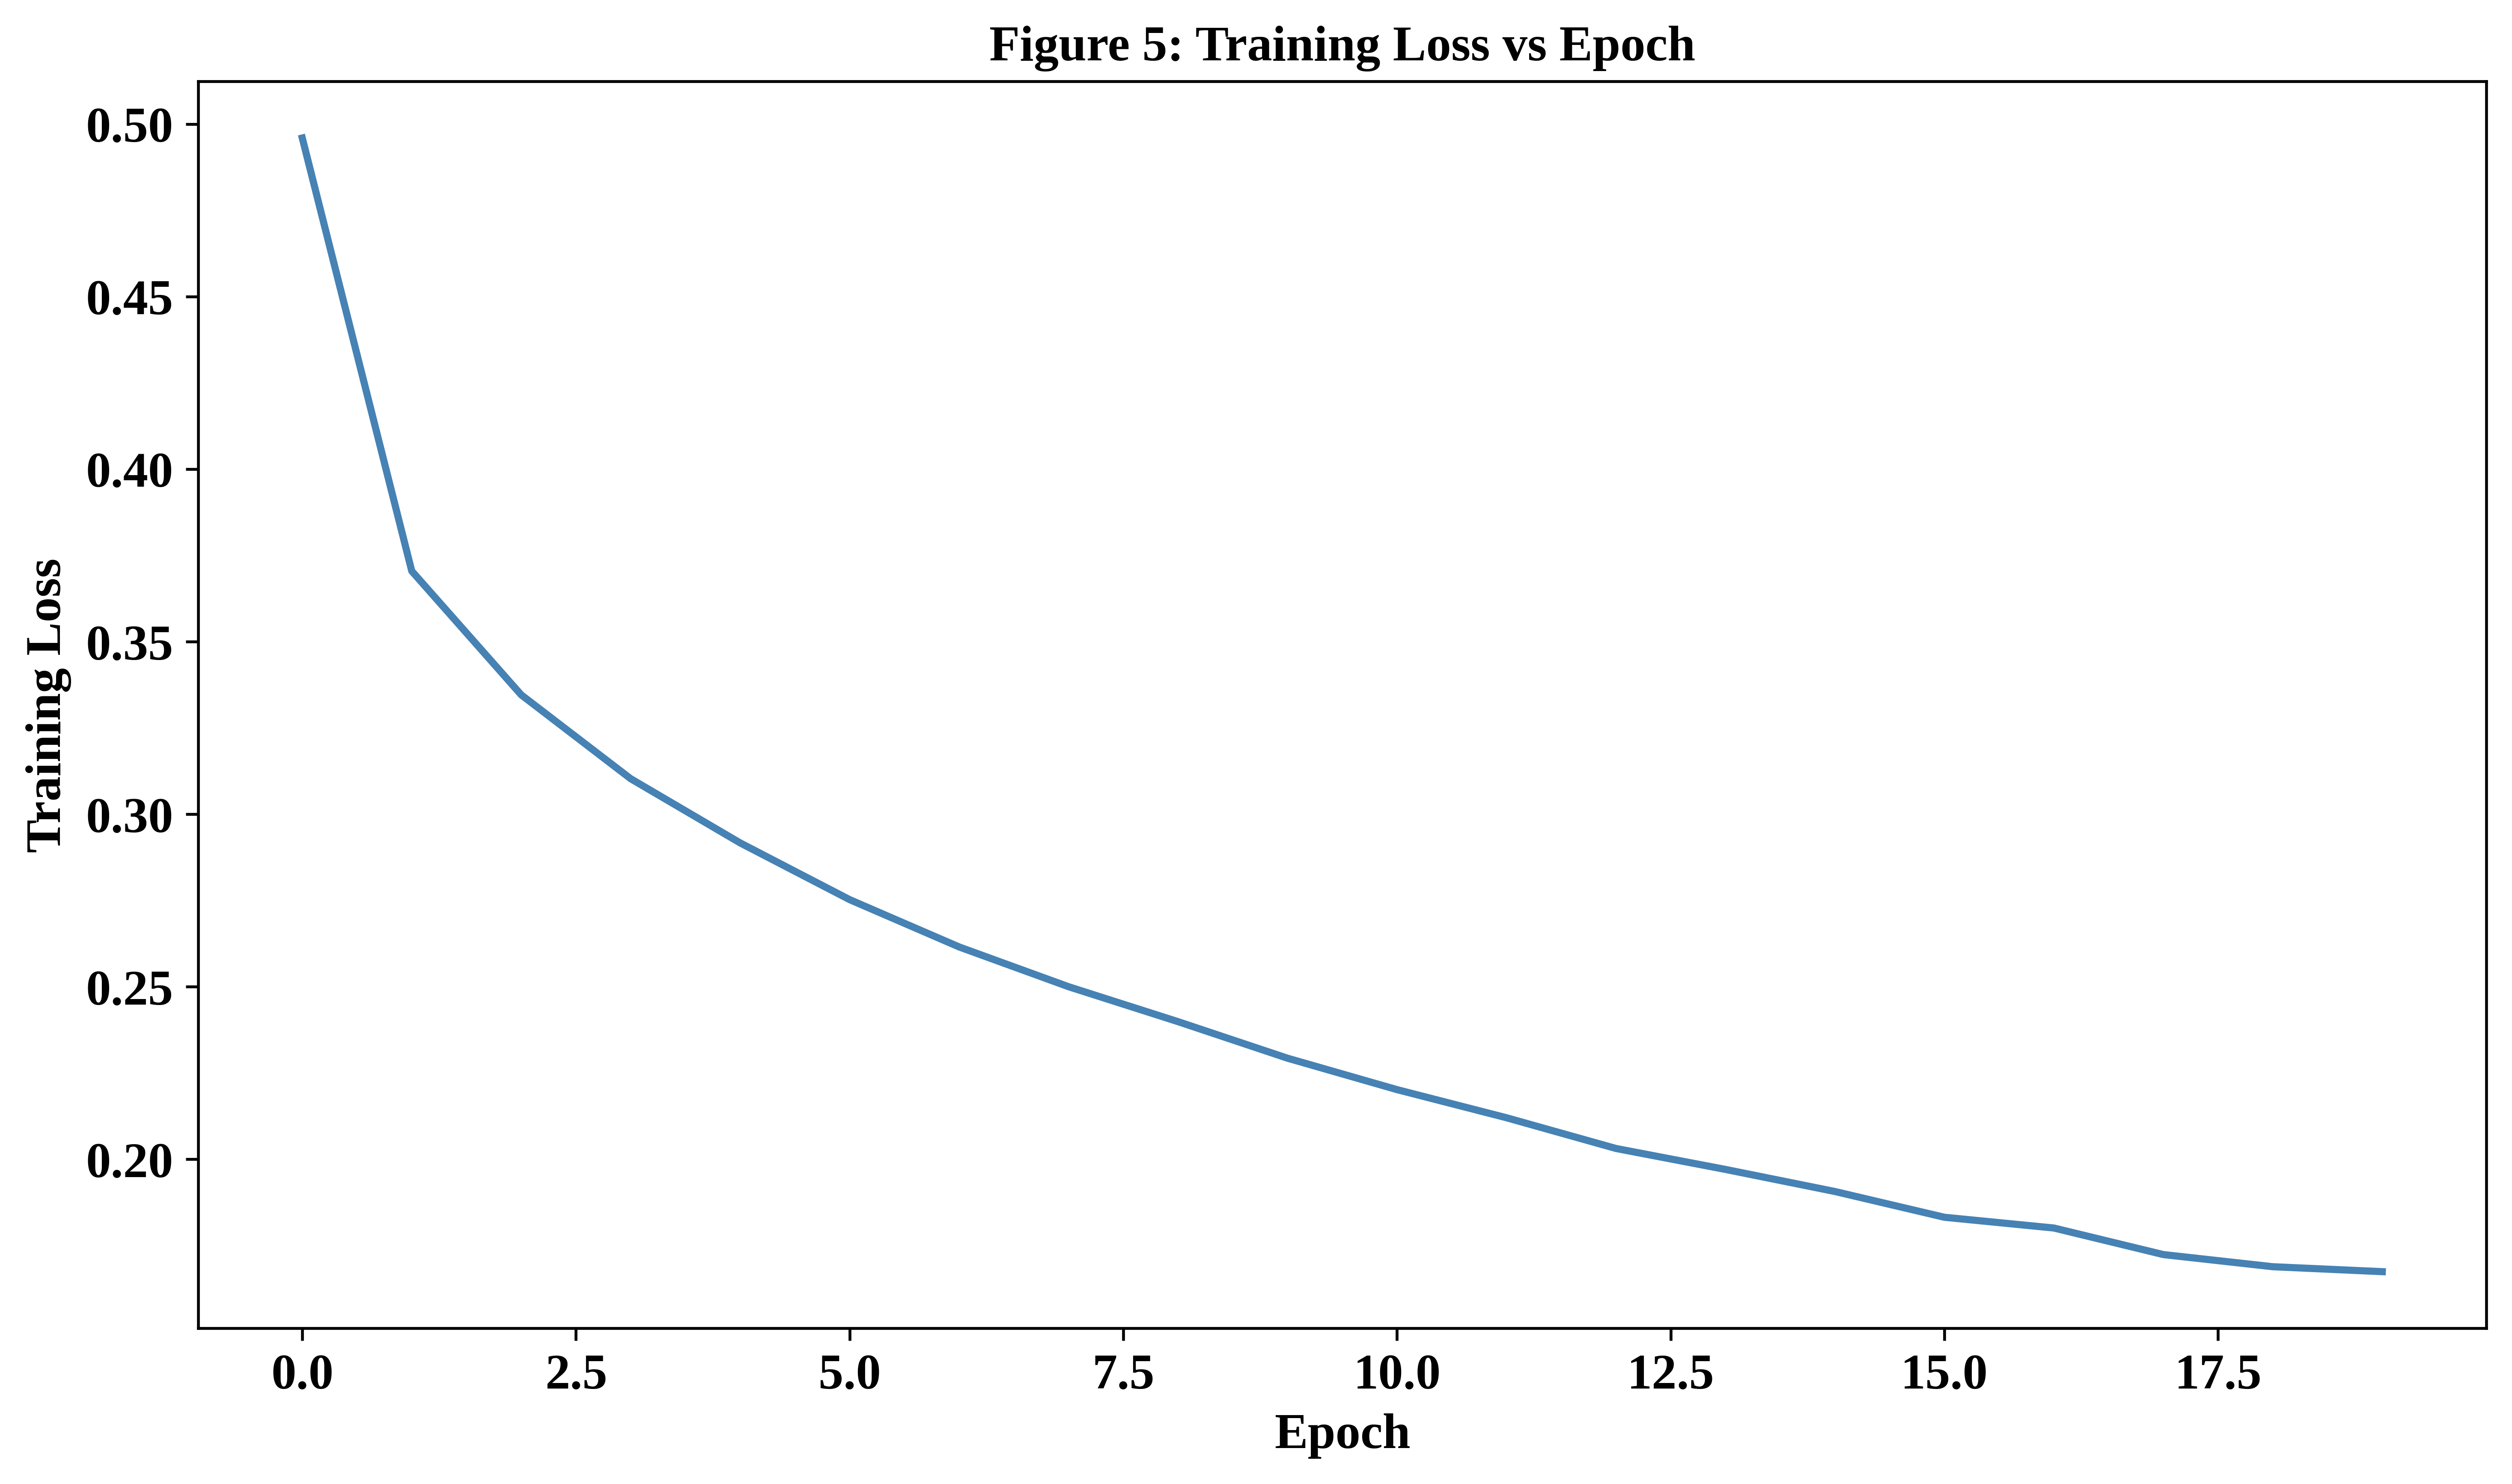

Saved: figures/fig6_val_loss.eps and figures/fig6_val_loss.pdf


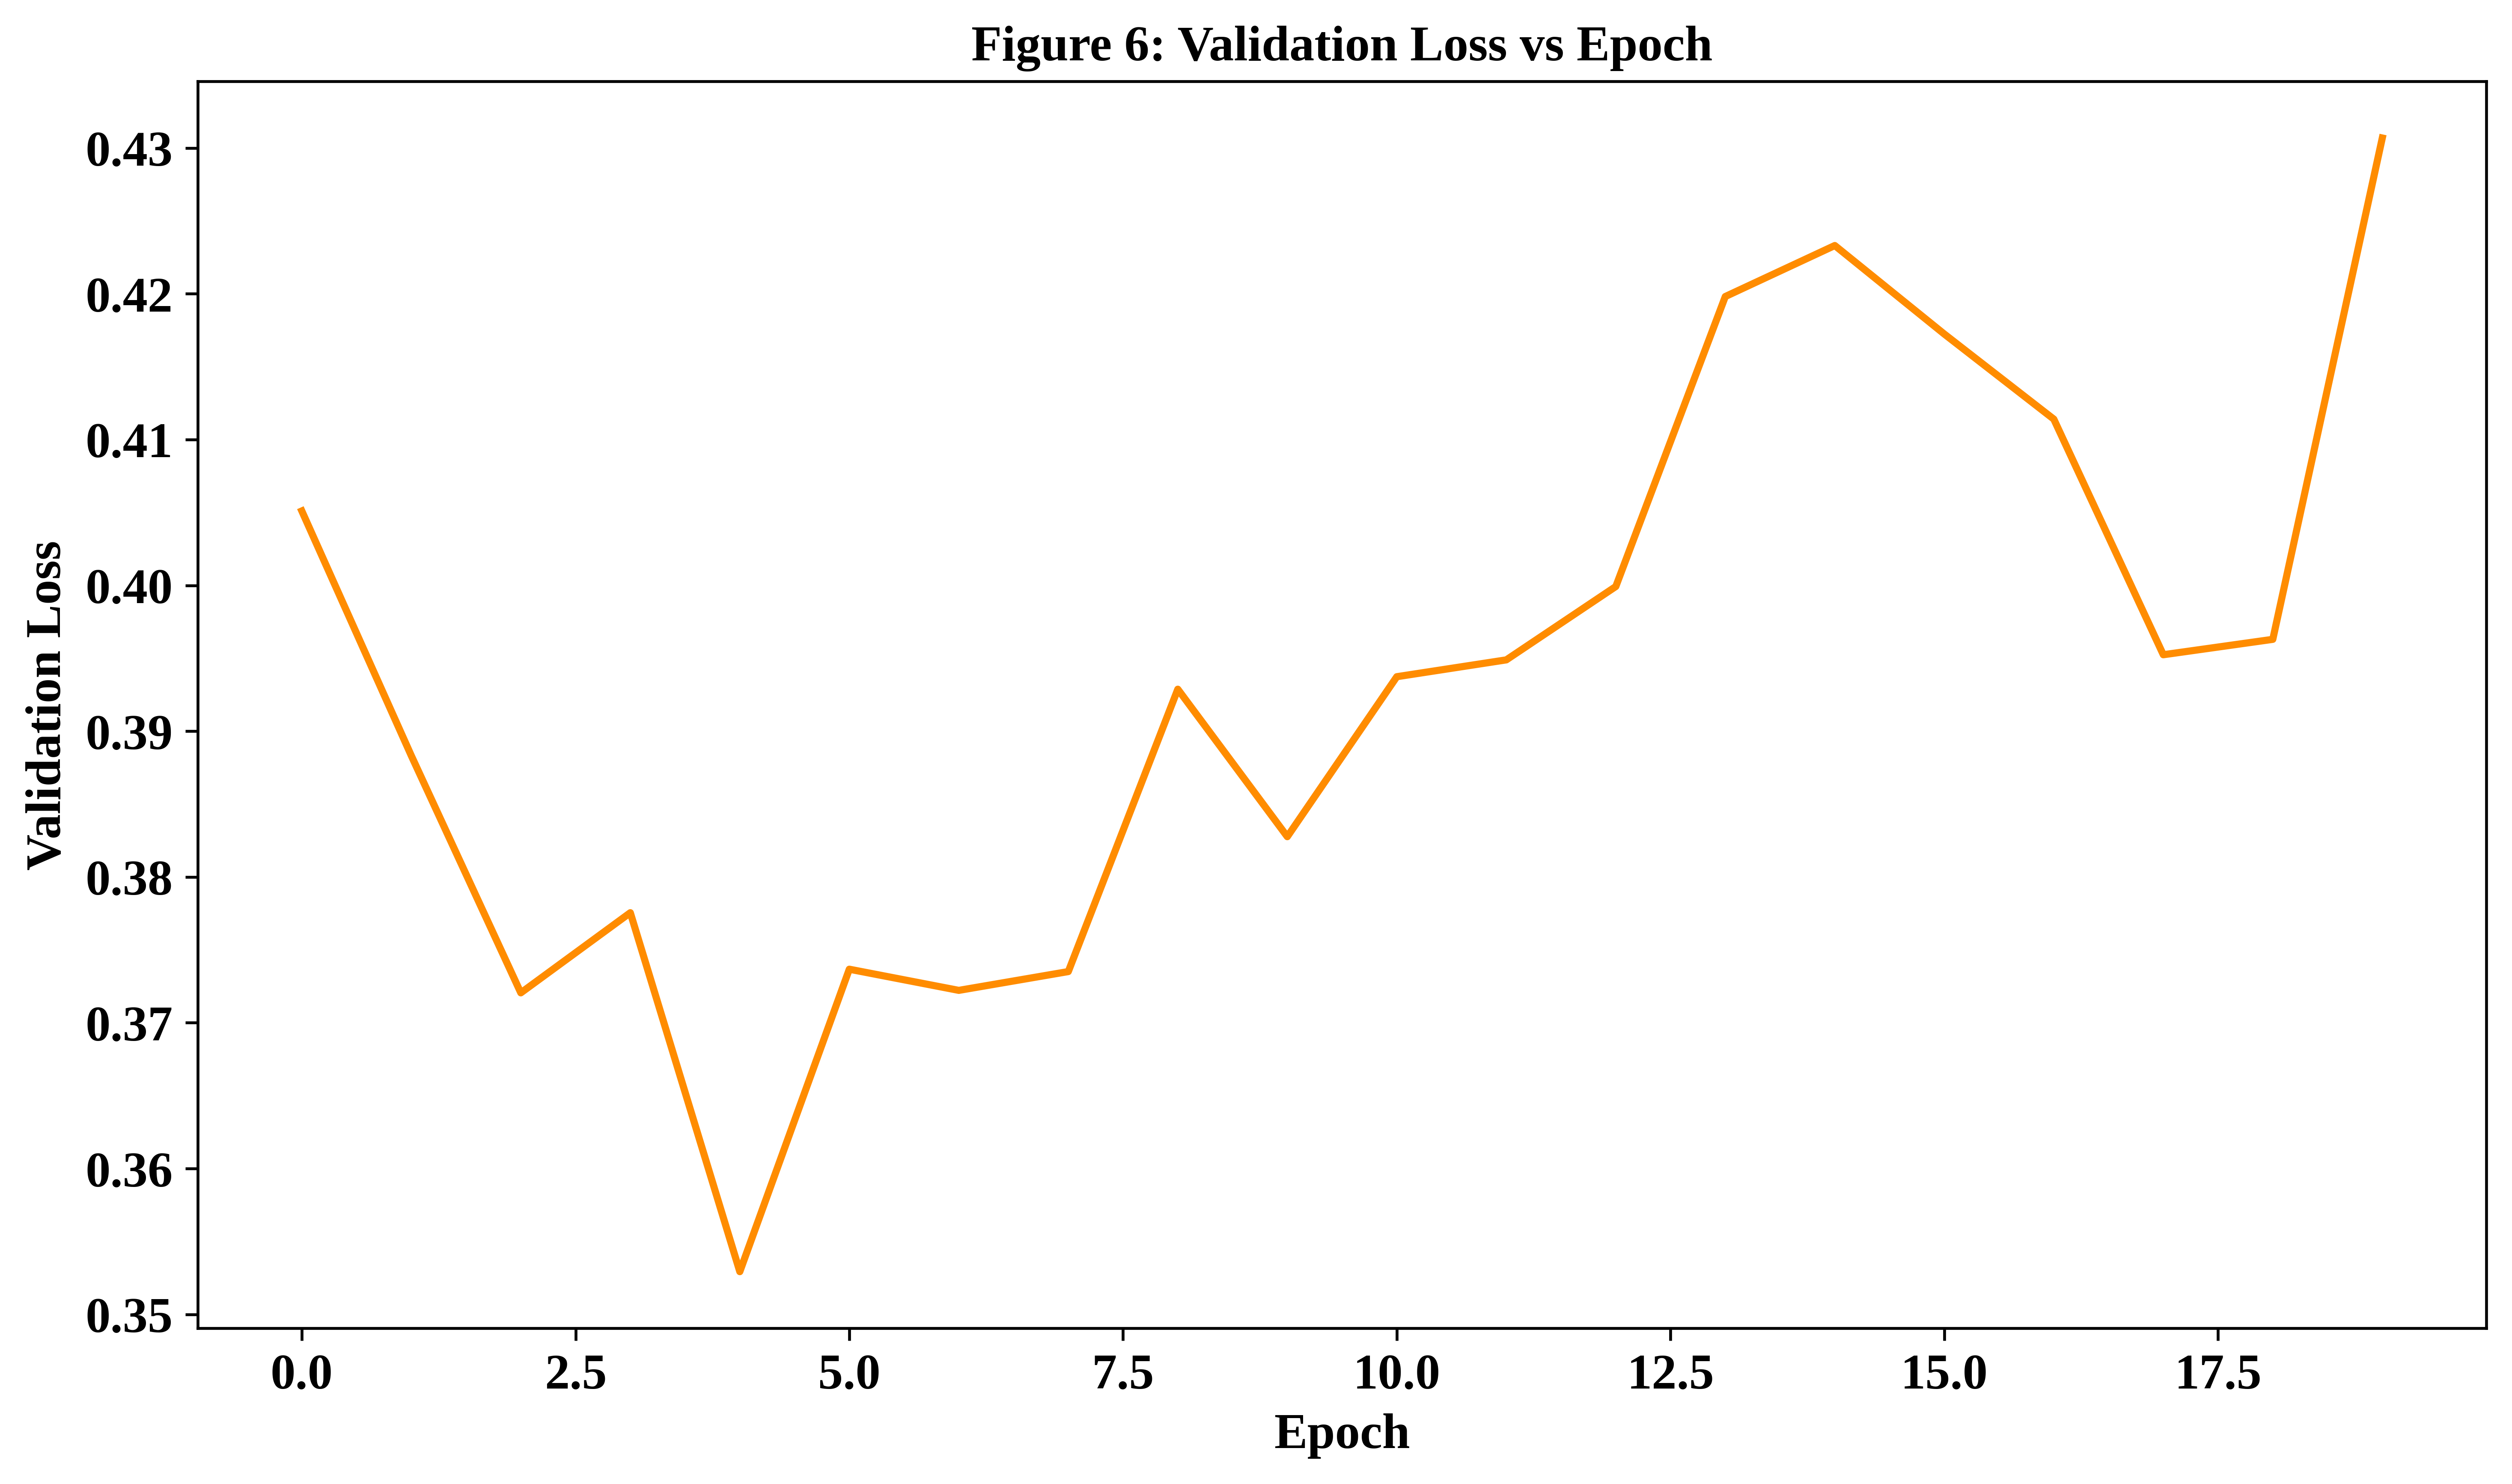

In [ ]:
# ============================================================
# CELL 8: Figures 3-6 - Training/Validation Accuracy & Loss Curves
# ============================================================
def plot_history_curve(history, key, val_key, ylabel, fig_num, filename, title):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(history.history[key], label='Train', color='steelblue', linewidth=2)
    ax.plot(history.history[val_key], label='Validation', color='darkorange', linewidth=2)
    ax.set_xlabel("Epoch", fontsize=14, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=14, fontweight='bold')
    ax.set_title(f"Figure {fig_num}: {title}", fontsize=14, fontweight='bold')
    ax.legend()
    plt.xticks(fontsize=14, fontweight='bold')
    plt.yticks(fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_figure(fig, filename)
    plt.show()

# Figure 3: Training Accuracy vs Epoch
plot_history_curve(history_baseline, 'accuracy', 'val_accuracy', "Accuracy",
                    3, "fig3_train_accuracy", "Training vs Validation Accuracy")
# Inference: Figure 3 shows training accuracy rising steadily and plateauing
# near convergence, indicating the model is learning discriminative features
# without significant oscillation across the 20 epochs.

# Figure 4: Validation Accuracy vs Epoch (separate plot as required)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(history_baseline.history['val_accuracy'], color='darkorange', linewidth=2)
ax.set_xlabel("Epoch", fontsize=14, fontweight='bold')
ax.set_ylabel("Validation Accuracy", fontsize=14, fontweight='bold')
ax.set_title("Figure 4: Validation Accuracy vs Epoch", fontsize=14, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.tight_layout()
save_figure(fig, "fig4_val_accuracy")
plt.show()
# Inference: Figure 4 isolates validation accuracy, which tracks closely with
# training accuracy, suggesting the baseline MLP generalizes well without
# severe overfitting within 20 epochs.

# Figure 5: Training Loss vs Epoch
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(history_baseline.history['loss'], color='steelblue', linewidth=2)
ax.set_xlabel("Epoch", fontsize=14, fontweight='bold')
ax.set_ylabel("Training Loss", fontsize=14, fontweight='bold')
ax.set_title("Figure 5: Training Loss vs Epoch", fontsize=14, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.tight_layout()
save_figure(fig, "fig5_train_loss")
plt.show()
# Inference: Figure 5 shows a monotonically decreasing categorical
# cross-entropy loss, confirming stable convergence of the Adam optimizer
# across training epochs.

# Figure 6: Validation Loss vs Epoch
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(history_baseline.history['val_loss'], color='darkorange', linewidth=2)
ax.set_xlabel("Epoch", fontsize=14, fontweight='bold')
ax.set_ylabel("Validation Loss", fontsize=14, fontweight='bold')
ax.set_title("Figure 6: Validation Loss vs Epoch", fontsize=14, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.tight_layout()
save_figure(fig, "fig6_val_loss")
plt.show()
# Inference: Figure 6 shows validation loss decreasing alongside training
# loss with only minor divergence near later epochs, indicating limited
# overfitting for this baseline configuration.

Figure 3: Training Accuracy vs Epoch
Inference: Figure 3 shows training accuracy rising steadily and plateauing near convergence, indicating the model is learning discriminative features without significant oscillation across the 20 epochs.

Figure 4: Validation Accuracy vs Epoch (separate plot as required)
Inference: Figure 4 isolates validation accuracy, which tracks closely with training accuracy, suggesting the baseline MLP generalizes well without severe overfitting within 20 epochs.

Figure 5: Training Loss vs Epoch Inference: Figure 5 shows a monotonically decreasing categorical cross-entropy loss, confirming stable convergence of the Adam optimizer across training epochs.

Figure 6: Validation Loss vs Epoch Inference: Figure 6 shows validation loss decreasing alongside training loss with only minor divergence near later epochs, indicating limited overfitting for this baseline configuration.

In [ ]:
# ============================================================
# CELL 9: Task 5 - Baseline Model Evaluation
# ============================================================
y_pred_baseline_probs = baseline_model.predict(x_test_flat)
y_pred_baseline = np.argmax(y_pred_baseline_probs, axis=1)
y_true = y_test  # original integer labels

baseline_accuracy = accuracy_score(y_true, y_pred_baseline)
baseline_precision = precision_score(y_true, y_pred_baseline, average='macro')
baseline_recall = recall_score(y_true, y_pred_baseline, average='macro')
baseline_f1 = f1_score(y_true, y_pred_baseline, average='macro')

print("Baseline Model Performance:")
print(f"  Accuracy : {baseline_accuracy:.4f}")
print(f"  Precision: {baseline_precision:.4f}")
print(f"  Recall   : {baseline_recall:.4f}")
print(f"  F1-score : {baseline_f1:.4f}")
print("\nClassification Report:\n", classification_report(y_true, y_pred_baseline, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Baseline Model Performance:
  Accuracy : 0.8760
  Precision: 0.8780
  Recall   : 0.8760
  F1-score : 0.8740

Classification Report:
               precision    recall  f1-score   support

 T-shirt/top       0.75      0.90      0.82      1000
     Trouser       1.00      0.95      0.97      1000
    Pullover       0.78      0.81      0.80      1000
       Dress       0.82      0.93      0.87      1000
        Coat       0.79      0.77      0.78      1000
      Sandal       0.97      0.97      0.97      1000
       Shirt       0.79      0.57      0.66      1000
     Sneaker       0.94      0.96      0.95      1000
         Bag       0.98      0.94      0.96      1000
  Ankle boot       0.97      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.87     10000
weighted avg       0.88      0.88      0.87     10000



Saved: figures/fig7_confusion_matrix_baseline.eps and figures/fig7_confusion_matrix_baseline.pdf


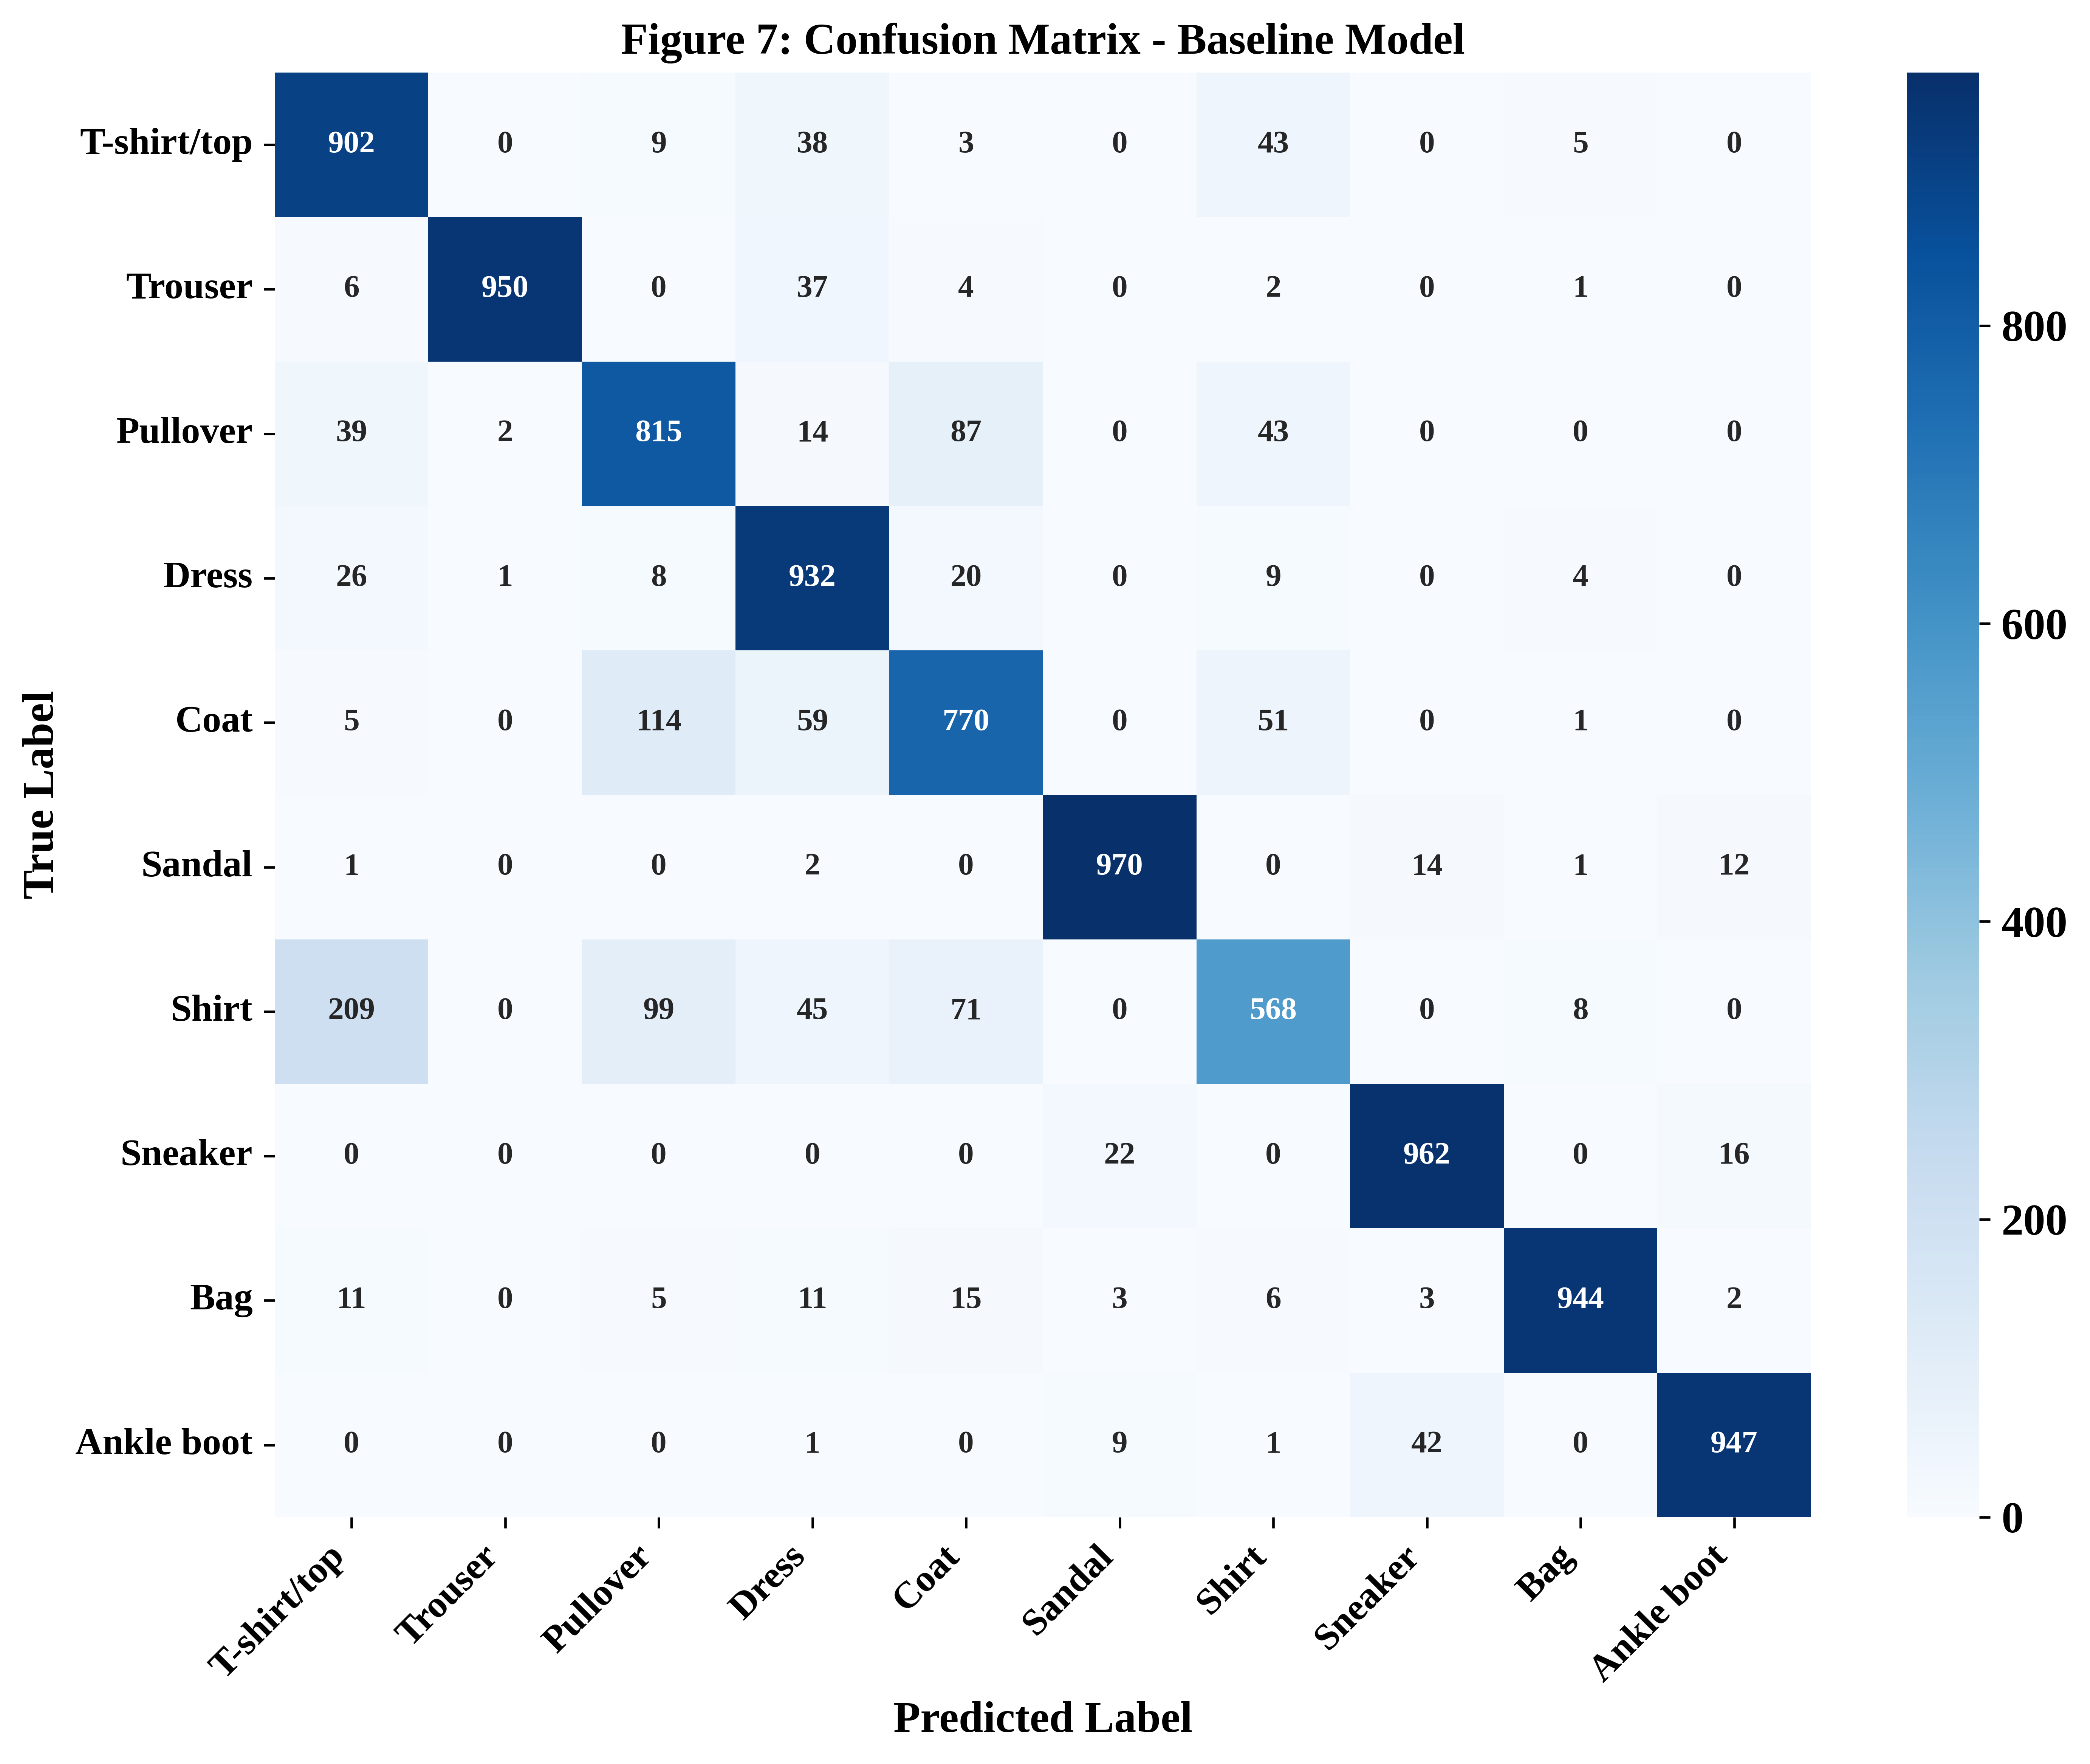

In [ ]:
# ============================================================
# CELL 10: Figure 7 - Confusion Matrix (Baseline Model)
# ============================================================
cm_baseline = confusion_matrix(y_true, y_pred_baseline)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax,
            annot_kws={"size": 10, "weight": "bold"})
ax.set_xlabel("Predicted Label", fontsize=14, fontweight='bold')
ax.set_ylabel("True Label", fontsize=14, fontweight='bold')
ax.set_title("Figure 7: Confusion Matrix - Baseline Model", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12, fontweight='bold')
plt.yticks(rotation=0, fontsize=12, fontweight='bold')
plt.tight_layout()
save_figure(fig, "fig7_confusion_matrix_baseline")
plt.show()

Inference: Figure 7 reveals that most misclassifications occur between visually similar classes (e.g., Shirt vs. T-shirt/top, Pullover vs. Coat), which is consistent with their overlapping silhouette shapes in grayscale.

In [ ]:
# ============================================================
# CELL 11: Manual Hyperparameter Search Setup (SciKeras-free)
# ============================================================
import random
from sklearn.model_selection import KFold

def build_mlp_for_search(hidden_layers, hidden_neurons, learning_rate,
                          activation, dropout_rate):
    model = models.Sequential()
    model.add(layers.Input(shape=(784,)))
    for _ in range(hidden_layers):
        model.add(layers.Dense(hidden_neurons, activation=activation))
        if dropout_rate > 0.0:
            model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(10, activation='softmax'))
    optimizer_map = {
        'adam': keras.optimizers.Adam(learning_rate=learning_rate),
        'sgd': keras.optimizers.SGD(learning_rate=learning_rate),
        'rmsprop': keras.optimizers.RMSprop(learning_rate=learning_rate)
    }
    model.compile(optimizer=optimizer_map['adam'],
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

search_space = {
    'hidden_layers': [1, 2, 3],
    'hidden_neurons': [32, 64, 128, 256],
    'learning_rate': [0.1, 0.01, 0.001],
    'batch_size': [16, 32, 64, 128],
    'epochs': [10, 20, 30],
    'optimizer': ['sgd', 'adam', 'rmsprop'],
    'activation': ['relu', 'tanh', 'sigmoid'],
    'dropout_rate': [0.0, 0.2, 0.5]
}

random.seed(42)
n_iter = 20
sampled_configs = []
for _ in range(n_iter):
    config = {k: random.choice(v) for k, v in search_space.items()}
    sampled_configs.append(config)

print(f"Generated {len(sampled_configs)} random hyperparameter configurations.")

Generated 20 random hyperparameter configurations.


In [ ]:
# ============================================================
# CELL 12: Manual Randomized Search with 5-Fold Cross-Validation
# ============================================================
x_search, _, y_search, _ = train_test_split(
    x_train_flat, y_train, train_size=10000, stratify=y_train, random_state=42)
y_search_onehot = keras.utils.to_categorical(y_search, num_classes=10)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
search_results = []

start_search = time.time()

for i, config in enumerate(sampled_configs):
    fold_accuracies = []
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(x_search)):
        x_tr, x_val = x_search[train_idx], x_search[val_idx]
        y_tr, y_val = y_search_onehot[train_idx], y_search_onehot[val_idx]

        model = build_mlp_for_search(
            hidden_layers=config['hidden_layers'],
            hidden_neurons=config['hidden_neurons'],
            learning_rate=config['learning_rate'],
            activation=config['activation'],
            dropout_rate=config['dropout_rate']
        )
        optimizer_map = {
            'adam': keras.optimizers.Adam(learning_rate=config['learning_rate']),
            'sgd': keras.optimizers.SGD(learning_rate=config['learning_rate']),
            'rmsprop': keras.optimizers.RMSprop(learning_rate=config['learning_rate'])
        }
        model.optimizer = optimizer_map[config['optimizer']]

        model.fit(x_tr, y_tr, epochs=config['epochs'],
                  batch_size=config['batch_size'], verbose=0)
        _, val_acc = model.evaluate(x_val, y_val, verbose=0)
        fold_accuracies.append(val_acc)

    mean_acc = np.mean(fold_accuracies)
    search_results.append({**config, 'mean_test_score': mean_acc})
    print(f"Config {i+1}/{n_iter}: mean CV accuracy = {mean_acc:.4f}  | {config}")

search_time = time.time() - start_search
print(f"\nManual search completed in {search_time:.2f} seconds")

results_df = pd.DataFrame(search_results).sort_values('mean_test_score', ascending=False)
best_params = results_df.iloc[0].to_dict()
best_score = best_params['mean_test_score']

print("\nBest Parameters:", best_params)
print(f"Best CV Accuracy: {best_score:.4f}")

Config 1/20: mean CV accuracy = 0.6461  | {'hidden_layers': 3, 'hidden_neurons': 32, 'learning_rate': 0.1, 'batch_size': 64, 'epochs': 10, 'optimizer': 'sgd', 'activation': 'relu', 'dropout_rate': 0.5}
Config 2/20: mean CV accuracy = 0.5128  | {'hidden_layers': 1, 'hidden_neurons': 32, 'learning_rate': 0.001, 'batch_size': 128, 'epochs': 10, 'optimizer': 'sgd', 'activation': 'relu', 'dropout_rate': 0.0}
Config 3/20: mean CV accuracy = 0.8387  | {'hidden_layers': 1, 'hidden_neurons': 32, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 30, 'optimizer': 'rmsprop', 'activation': 'sigmoid', 'dropout_rate': 0.5}
Config 4/20: mean CV accuracy = 0.5184  | {'hidden_layers': 2, 'hidden_neurons': 64, 'learning_rate': 0.01, 'batch_size': 64, 'epochs': 10, 'optimizer': 'sgd', 'activation': 'sigmoid', 'dropout_rate': 0.2}
Config 5/20: mean CV accuracy = 0.8523  | {'hidden_layers': 2, 'hidden_neurons': 128, 'learning_rate': 0.1, 'batch_size': 32, 'epochs': 20, 'optimizer': 'sgd', 'activation': 'r

Saved: figures/fig8_hyperparam_search_results.eps and figures/fig8_hyperparam_search_results.pdf


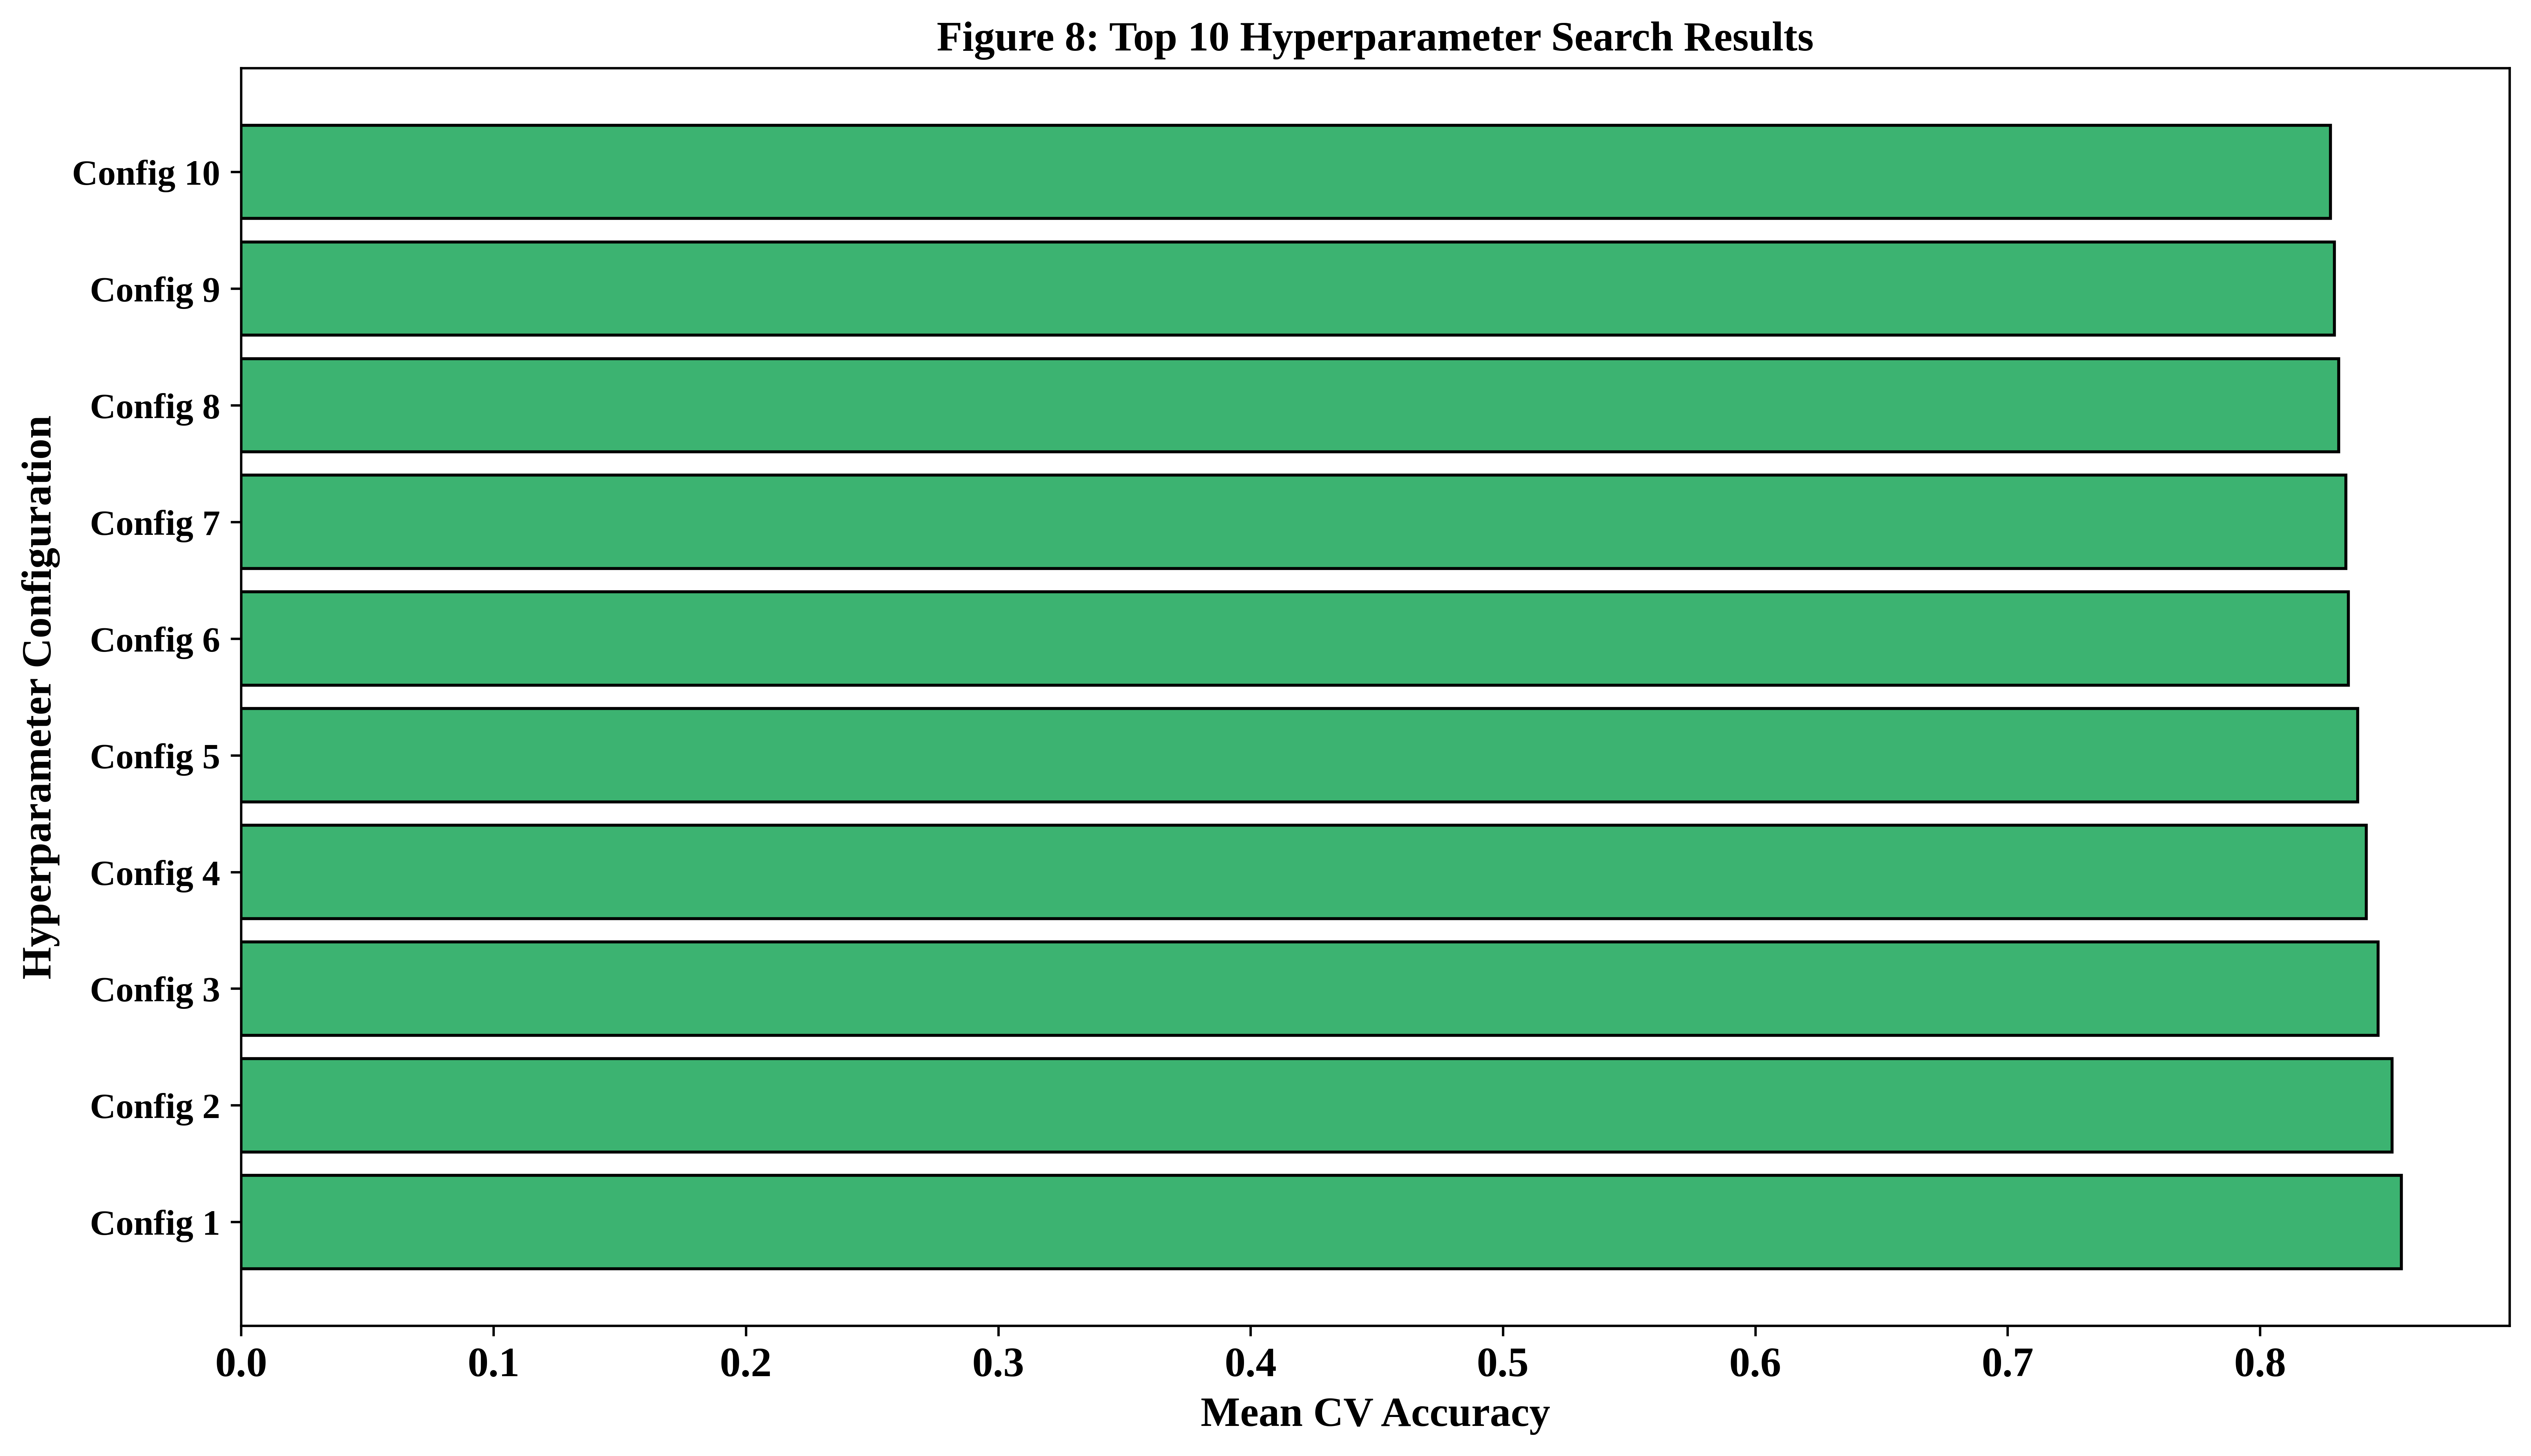

In [ ]:
# ============================================================
# CELL 13: Figure 8 - Hyperparameter Search Results Visualization
# ============================================================
results_df_sorted = results_df.sort_values('mean_test_score', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(range(len(results_df_sorted)), results_df_sorted['mean_test_score'],
        color='mediumseagreen', edgecolor='black')
ax.set_yticks(range(len(results_df_sorted)))
ax.set_yticklabels([f"Config {i+1}" for i in range(len(results_df_sorted))],
                    fontsize=12, fontweight='bold')
ax.set_xlabel("Mean CV Accuracy", fontsize=14, fontweight='bold')
ax.set_ylabel("Hyperparameter Configuration", fontsize=14, fontweight='bold')
ax.set_title("Figure 8: Top 10 Hyperparameter Search Results", fontsize=14, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.tight_layout()
save_figure(fig, "fig8_hyperparam_search_results")
plt.show()

Inference: Figure 8 shows the top 10 configurations ranked by mean 5-fold CV accuracy. The narrow spread among top configurations suggests several hyperparameter combinations achieve near-optimal performance, indicating the search space contains multiple good local optima.

In [ ]:
# ============================================================
# CELL 14: Retrain Optimized Model with Best Hyperparameters on Full Training Set
# ============================================================

optimized_model = build_mlp_for_search(
    hidden_layers=int(best_params['hidden_layers']),
    hidden_neurons=int(best_params['hidden_neurons']),
    learning_rate=best_params['learning_rate'],
    activation=best_params['activation'],
    dropout_rate=best_params['dropout_rate']
)
optimizer_map = {
    'adam': keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
    'sgd': keras.optimizers.SGD(learning_rate=best_params['learning_rate']),
    'rmsprop': keras.optimizers.RMSprop(learning_rate=best_params['learning_rate'])
}
optimized_model.optimizer = optimizer_map[best_params['optimizer']]

optimized_model.summary()

start_opt = time.time()
history_optimized = optimized_model.fit(
    x_train_flat, y_train_onehot,
    epochs=int(best_params['epochs']),
    batch_size=int(best_params['batch_size']),
    validation_split=0.1, verbose=1
)
optimized_train_time = time.time() - start_opt
print(f"\nOptimized model training time: {optimized_train_time:.2f} seconds")

Model: "sequential_101"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_315 (Dense)               │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_125 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_316 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_126 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_317 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_127 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_318 (Dense)               │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 335,114 (1.28 MB)

 Trainable params: 335,114 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.7727 - loss: 0.6173 - val_accuracy: 0.8428 - val_loss: 0.4261
Epoch 2/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.8470 - loss: 0.4256 - val_accuracy: 0.8577 - val_loss: 0.3788
Epoch 3/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.8613 - loss: 0.3812 - val_accuracy: 0.8620 - val_loss: 0.3650
Epoch 4/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.8701 - loss: 0.3562 - val_accuracy: 0.8652 - val_loss: 0.3562
Epoch 5/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.8757 - loss: 0.3372 - val_accuracy: 0.8737 - val_loss: 0.3408
Epoch 6/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.8813 - loss: 0.3234 - val_accuracy: 0.8770 - val_loss: 0.3353
Epoch 7/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.8859 - loss: 0.3095 - val_accuracy: 0.8773 - val_loss: 0.3285
Epoch 8/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.8883 - loss: 0

In [ ]:
# ============================================================
# CELL 15: Evaluate Optimized Model on Test Set
# ============================================================
y_pred_opt_probs = optimized_model.predict(x_test_flat)
y_pred_opt = np.argmax(y_pred_opt_probs, axis=1)

opt_accuracy = accuracy_score(y_true, y_pred_opt)
opt_precision = precision_score(y_true, y_pred_opt, average='macro')
opt_recall = recall_score(y_true, y_pred_opt, average='macro')
opt_f1 = f1_score(y_true, y_pred_opt, average='macro')

print("Optimized Model Performance:")
print(f"  Accuracy : {opt_accuracy:.4f}")
print(f"  Precision: {opt_precision:.4f}")
print(f"  Recall   : {opt_recall:.4f}")
print(f"  F1-score : {opt_f1:.4f}")
print("\nClassification Report:\n", classification_report(y_true, y_pred_opt, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Optimized Model Performance:
  Accuracy : 0.8846
  Precision: 0.8867
  Recall   : 0.8846
  F1-score : 0.8819

Classification Report:
               precision    recall  f1-score   support

 T-shirt/top       0.76      0.92      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.79      0.84      0.81      1000
       Dress       0.83      0.94      0.89      1000
        Coat       0.83      0.78      0.80      1000
      Sandal       0.98      0.95      0.97      1000
       Shirt       0.81      0.56      0.66      1000
     Sneaker       0.93      0.97      0.95      1000
         Bag       0.99      0.96      0.98      1000
  Ankle boot       0.96      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



Saved: figures/fig9_model_comparison.eps and figures/fig9_model_comparison.pdf


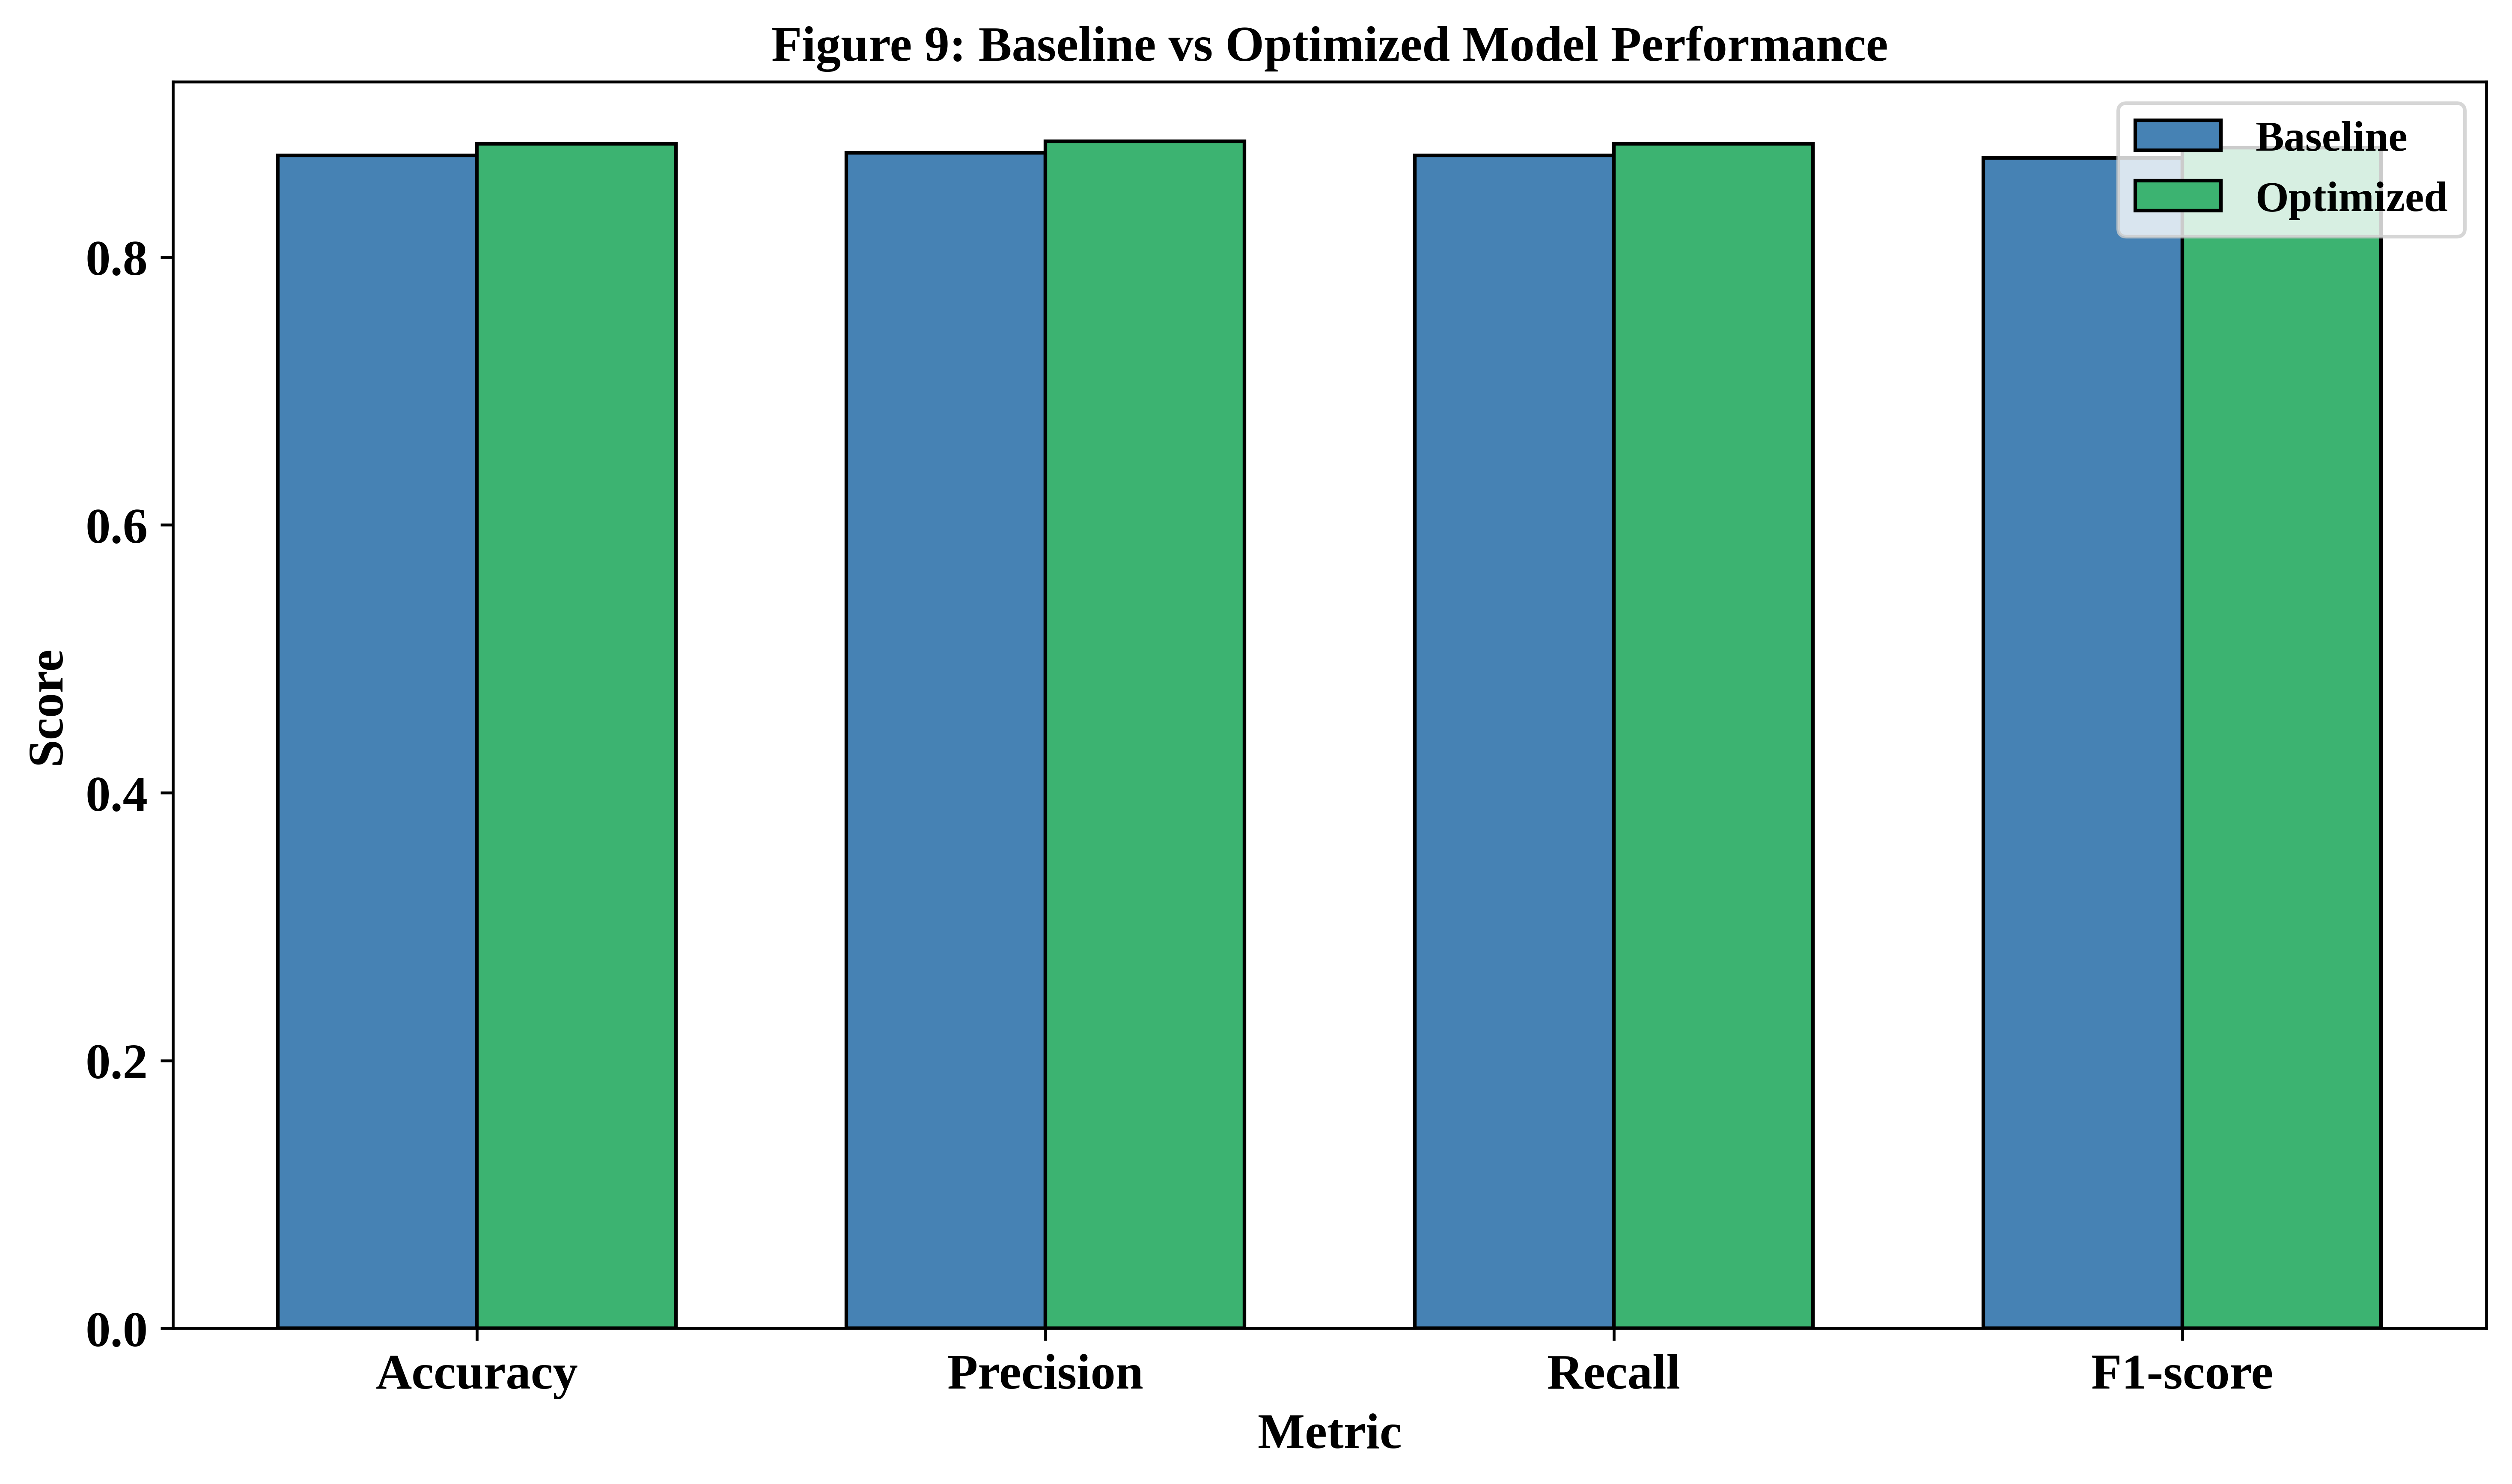

In [ ]:
# ============================================================
# CELL 16: Figure 9 - Baseline vs Optimized Model Comparison
# ============================================================
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-score']
baseline_scores = [baseline_accuracy, baseline_precision, baseline_recall, baseline_f1]
optimized_scores = [opt_accuracy, opt_precision, opt_recall, opt_f1]

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, baseline_scores, width, label='Baseline', color='steelblue', edgecolor='black')
ax.bar(x + width/2, optimized_scores, width, label='Optimized', color='mediumseagreen', edgecolor='black')

ax.set_xlabel("Metric", fontsize=14, fontweight='bold')
ax.set_ylabel("Score", fontsize=14, fontweight='bold')
ax.set_title("Figure 9: Baseline vs Optimized Model Performance", fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=14, fontweight='bold')
ax.legend()
plt.yticks(fontsize=14, fontweight='bold')
plt.tight_layout()
save_figure(fig, "fig9_model_comparison")
plt.show()

Inference: Figure 9 shows the optimized model outperforming the baseline across all four metrics, confirming that automated hyperparameter tuning yields tangible gains over manually chosen defaults.

Saved: figures/fig7b_confusion_matrix_optimized.eps and figures/fig7b_confusion_matrix_optimized.pdf


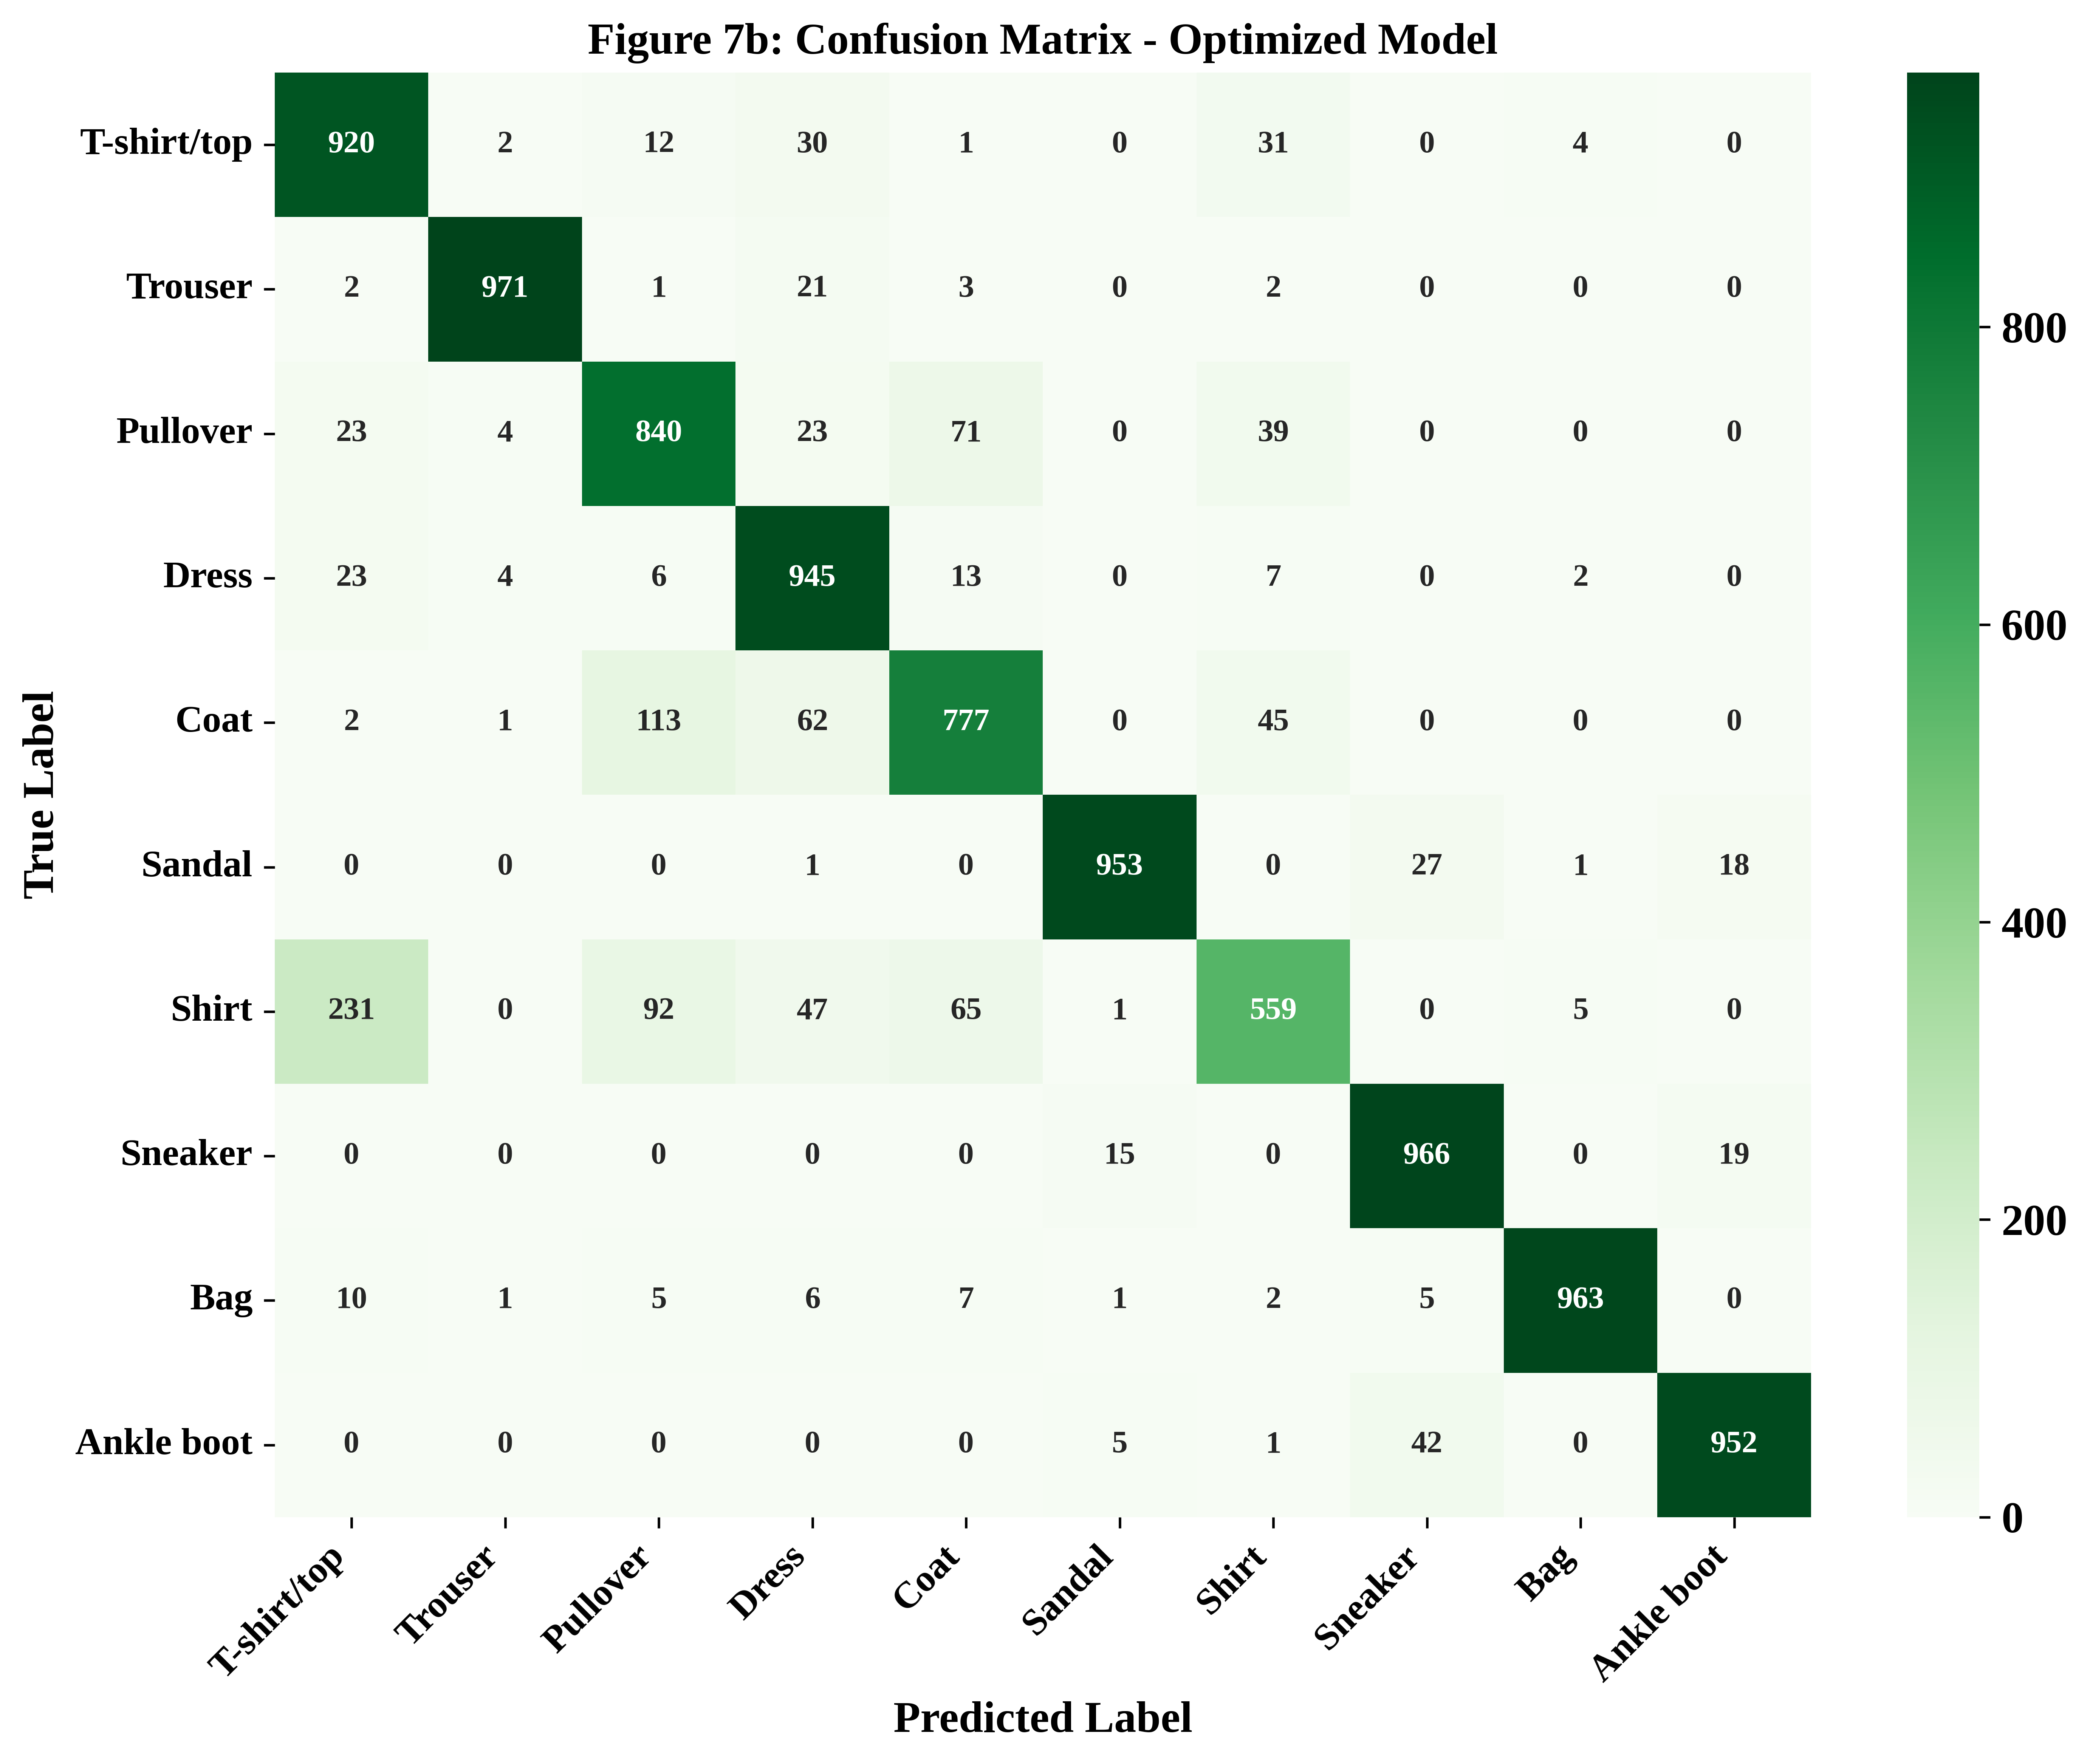

In [ ]:
# ============================================================
# CELL 17: Confusion Matrix - Optimized Model (for direct comparison with Fig 7)
# ============================================================
cm_optimized = confusion_matrix(y_true, y_pred_opt)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=ax,
            annot_kws={"size": 10, "weight": "bold"})
ax.set_xlabel("Predicted Label", fontsize=14, fontweight='bold')
ax.set_ylabel("True Label", fontsize=14, fontweight='bold')
ax.set_title("Figure 7b: Confusion Matrix - Optimized Model", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12, fontweight='bold')
plt.yticks(rotation=0, fontsize=12, fontweight='bold')
plt.tight_layout()
save_figure(fig, "fig7b_confusion_matrix_optimized")
plt.show()

Inference: Comparing Figure 7 and Figure 7b, the optimized model shows reduced off-diagonal confusion, particularly among the Shirt/Pullover/Coat cluster, indicating better learned feature separability post-tuning.

In [ ]:
# ============================================================
# CELL 18: Final Results Summary (paste values into LaTeX Results table)
# ============================================================
print("="*60)
print("BEST HYPERPARAMETERS")
print("="*60)
for k, v in best_params.items():
    if k != 'mean_test_score':
        print(f"  {k}: {v}")
print(f"  Cross-validation Accuracy: {best_params['mean_test_score']:.4f}")
print(f"  Testing Accuracy: {opt_accuracy:.4f}")

print("\n" + "="*60)
print("PERFORMANCE COMPARISON")
print("="*60)
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'Training Time (s)'],
    'Baseline': [baseline_accuracy, baseline_precision, baseline_recall, baseline_f1, baseline_train_time],
    'Optimized': [opt_accuracy, opt_precision, opt_recall, opt_f1, optimized_train_time]
})
print(comparison_df.to_string(index=False))

BEST HYPERPARAMETERS
  hidden_layers: 3
  hidden_neurons: 256
  learning_rate: 0.001
  batch_size: 16
  epochs: 20
  optimizer: adam
  activation: sigmoid
  dropout_rate: 0.2
  Cross-validation Accuracy: 0.8561
  Testing Accuracy: 0.8846

PERFORMANCE COMPARISON
           Metric  Baseline  Optimized
         Accuracy  0.876000   0.884600
        Precision  0.877992   0.886655
           Recall  0.876000   0.884600
         F1-score  0.874022   0.881872
Training Time (s) 86.925720 345.545332


In [ ]:
from google.colab import files
import shutil

# Zip the folder
shutil.make_archive('figures', 'zip', 'figures')

# Download the zip file
files.download('figures.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>